Connected to DebrisRemoval (Python 3.12.4)

In [ ]:
import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
print("Setting up environment...")

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
critical_path = os.path.join(input_base, 'focus_area_fire_station.csv')
raster_path = os.path.join(input_base, 'Raster Data.tif')
output_vrp_path = os.path.join(output_dir, 'Phase1_Debris_Final.vrp')

# Parameters
SPEED_MPH = 10
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
DEBRIS_TRAVEL_PENALTY_MIN = 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# LKH Constraints
CAPACITY_LIMIT = 480  # Max Piling Time per truck
DISTANCE_LIMIT = 600  # Max Travel+Service Time per truck
VEHICLES_COUNT = 5    # Increased to ensure feasibility
NUM_RESIDENTIAL_NODES = 20

# ==========================================
# 2. LOAD DATA
# ==========================================
print("Loading Spatial Data...")
df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_critical = pd.read_csv(critical_path)

# Convert WKT
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
df_critical['geometry'] = df_critical['WKT'].apply(wkt.loads)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_critical = gpd.GeoDataFrame(df_critical, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")

Setting up environment...
Loading Spatial Data...


In [ ]:
# ==========================================
# 3. IDENTIFY BLOCKED ROADS
# ==========================================
print("Identifying Blocked Roads...")
blocked_status = []

with rasterio.open(raster_path) as src:
    # Reproject edges to match Raster CRS
    gdf_edges_raster_crs = gdf_edges.to_crs(src.crs)
    
    # Calculate buffer (Rough approximation if Degrees, Exact if Meters)
    if src.res[0] < 0.1: 
        buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
    else: 
        buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

    for idx, row in gdf_edges_raster_crs.iterrows():
        try:
            road_geom = row['geometry'].buffer(buffer_width)
            out_image, _ = mask(src, [road_geom], crop=True)
            
            valid_mask = out_image[0] >= 0
            if valid_mask.sum() == 0:
                blocked_status.append(0)
                continue

            debris_pixels = (out_image[0] > 0).sum()
            total_pixels = valid_mask.sum()
            
            if (debris_pixels / total_pixels) >= BLOCKAGE_THRESHOLD:
                blocked_status.append(1)
            else:
                blocked_status.append(0)
        except:
            blocked_status.append(0)

df_edges['blocked'] = blocked_status

Identifying Blocked Roads...


In [ ]:
# ==========================================
# 4. BUILD INITIAL GRAPH
# ==========================================
print("Building Initial Graph...")
G_raw = nx.Graph()

# Add all nodes first (to ensure ID existence)
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges with weights
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    # Calculate weight
    w = row['length'] / SPEED_METERS_PER_MIN
    if row['blocked'] == 1:
        w += DEBRIS_TRAVEL_PENALTY_MIN
    
    # Add edge
    if G_raw.has_node(u) and G_raw.has_node(v):
        G_raw.add_edge(u, v, weight=w, blocked=row['blocked'])

Building Initial Graph...


In [ ]:
# ==========================================
# 5. CLEAN GRAPH (REMOVE ISOLATED NODES)
# ==========================================
print("Cleaning Graph (Removing Disconnected Islands)...")
# Get Largest Connected Component
largest_cc = max(nx.connected_components(G_raw), key=len)
G = G_raw.subgraph(largest_cc).copy()

print(f"  > Original Nodes: {len(G_raw.nodes)}")
print(f"  > Cleaned Nodes: {len(G.nodes)}")
print(f"  > Removed {len(G_raw.nodes) - len(G.nodes)} unreachable nodes.")

Cleaning Graph (Removing Disconnected Islands)...
  > Original Nodes: 227
  > Cleaned Nodes: 224
  > Removed 3 unreachable nodes.


In [ ]:
# ==========================================
# 6. RENUMBER NODES (OSMID -> 1..N)
# ==========================================
# We must re-index 1 to N based on the CLEANED graph
final_nodes = list(G.nodes())
osmid_to_lkh = {osmid: i+1 for i, osmid in enumerate(final_nodes)}
lkh_to_osmid = {i+1: osmid for i, osmid in enumerate(final_nodes)}
total_nodes = len(final_nodes)

In [ ]:
# ==========================================
# 7. MAP SPECIAL NODES (Depot/Critical/Res)
# ==========================================
print("Mapping Special Nodes...")

# Helper: Find closest VALID node in the CLEANED graph
def get_closest_valid_node(point, nodes_gdf, valid_osmids):
    if nodes_gdf.crs != "EPSG:3857":
        nodes_gdf = nodes_gdf.to_crs("EPSG:3857")
    
    # Filter GeoDataFrame to only valid nodes
    valid_nodes_gdf = nodes_gdf[nodes_gdf['osmid'].isin(valid_osmids)].copy()
    
    pt_proj = gpd.GeoSeries([point], crs="EPSG:4326").to_crs("EPSG:3857")[0]
    distances = valid_nodes_gdf.geometry.distance(pt_proj)
    closest_osmid = valid_nodes_gdf.loc[distances.idxmin(), 'osmid']
    return osmid_to_lkh[closest_osmid]

# 1. Depot
depot_pt = wkt.loads(df_depot.iloc[0]['WKT'])
depot_id = get_closest_valid_node(depot_pt, gdf_nodes_proj, final_nodes)

# 2. Critical
critical_ids = []
for _, row in df_critical.iterrows():
    nid = get_closest_valid_node(row['geometry'], gdf_nodes_proj, final_nodes)
    critical_ids.append(nid)
critical_ids = list(set(critical_ids))

# 3. Residential (Random Sample)
available = [n for n in range(1, total_nodes+1) if n != depot_id and n not in critical_ids]
if len(available) < NUM_RESIDENTIAL_NODES:
    residential_ids = available
else:
    residential_ids = random.sample(available, NUM_RESIDENTIAL_NODES)

Mapping Special Nodes...


In [ ]:
# ==========================================
# 8. GENERATE FULL COST MATRIX (APSP)
# ==========================================
print("Generating All-Pairs Shortest Path Matrix...")
# Because G is fully connected, we won't get infinite values here
# This solves the "LKH Cheating" issue by providing valid paths between ALL nodes

# Remap graph to LKH IDs for calculation
G_lkh = nx.relabel_nodes(G, osmid_to_lkh)

# Calculate Matrix using Floyd-Warshall (or repeated Dijkstra for large graphs)
# Using repeated Dijkstra here as it handles weights reliably
matrix_rows = []

for i in range(1, total_nodes + 1):
    # Shortest paths from i to ALL other nodes
    length_dict = nx.single_source_dijkstra_path_length(G_lkh, i, weight='weight')
    
    row_vals = []
    for j in range(1, total_nodes + 1):
        if i == j:
            row_vals.append(999999) # Cost to self
        else:
            # If graph is connected, length_dict[j] should always exist
            cost = length_dict.get(j, 999999) 
            row_vals.append(int(cost))
    
    matrix_rows.append(" ".join(map(str, row_vals)))

Generating All-Pairs Shortest Path Matrix...


In [ ]:
# ==========================================
# 9. CALCULATE DEMANDS & WINDOWS
# ==========================================
demands = {}
time_windows = {}

TW_CRITICAL = (0, int(DISTANCE_LIMIT * 0.25))
TW_RESIDENTIAL = (0, int(DISTANCE_LIMIT * 0.50))
TW_STANDARD = (0, DISTANCE_LIMIT * 5) # Open window

for i in range(1, total_nodes + 1):
    # DEMAND (Blocked Edges)
    edges = G_lkh.edges(i, data=True)
    blocked_count = sum(1 for u, v, d in edges if d.get('blocked') == 1)
    
    if blocked_count == 0: dem = 0
    elif blocked_count == 1: dem = 60
    elif blocked_count == 2: dem = 120
    elif blocked_count == 3: dem = 180
    else: dem = 240
    demands[i] = dem

    # WINDOWS
    if i == depot_id:
        time_windows[i] = (0, DISTANCE_LIMIT)
    elif i in critical_ids:
        time_windows[i] = TW_CRITICAL
    elif i in residential_ids:
        time_windows[i] = TW_RESIDENTIAL
    else:
        time_windows[i] = TW_STANDARD

In [ ]:
# ==========================================
# 10. WRITE VRP & PRINT INFO
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase1_Final\n")
    f.write("TYPE : CVRPTW\n")
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("SERVICE_TIME : 0\n")
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("DEMAND_SECTION\n")
    for i in range(1, total_nodes + 1):
        f.write(f"{i} {demands[i]}\n")
        
    f.write("TIME_WINDOW_SECTION\n")
    for i in range(1, total_nodes + 1):
        s, e = time_windows[i]
        f.write(f"{i} {s} {e}\n")
        
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\n" + "="*30)
print("       NODE INFORMATION")
print("="*30)
print(f"Total Nodes in Network: {total_nodes}")
print(f"Depot Node ID: {depot_id}")
print(f"Critical Nodes (Fire Stations): {critical_ids}")
print(f"Residential Nodes (Random): {residential_ids}")
print("="*30)

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp...

       NODE INFORMATION
Total Nodes in Network: 224
Depot Node ID: 66
Critical Nodes (Fire Stations): [219]
Residential Nodes (Random): [63, 189, 71, 107, 106, 61, 55, 47, 165, 173, 22, 176, 51, 218, 152, 5, 163, 221, 82, 91]


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\CVRP\INSTANCES\Augerat_A\A-n32-k5.vrp"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\CVRP\INSTANCES\Augerat_A\Phase1_Debris_Clearance.vrp"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\DCVRP\INSTANCES\GWKC\D022-04g.vrp"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\CVRPTW\CVRPTW\INSTANCES\Homberger_200\C1_2_1.200.20.vrptw"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\input\LKH\D022-04g_dis_mat.vrp"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\input\LKH\Phase1_DebrisPass.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.1805 seconds
Best Routes Found: [[163, 48, 56, 218, 17, 62, 57, 46, 49, 222, 221, 43, 65, 116, 19, 61, 115, 51, 136, 60, 28, 55, 137, 135, 134, 152, 160, 154, 159, 157, 1, 4, 130, 128, 2, 156, 14, 151, 132, 23, 69, 22], [41, 21], [72, 223, 117, 113, 195, 12, 84, 82, 85, 102, 106, 105, 101, 91, 197, 119, 121, 109, 104, 190, 24, 87, 123, 89, 193, 26, 107, 15, 7, 6, 83, 98, 16, 5, 79, 103, 93, 111, 199, 155, 68, 13, 27, 192, 110, 198, 125, 158, 148, 131, 122, 71], [42, 75], [20, 76], [78, 95, 126, 194, 88, 114, 96, 99, 80, 86, 25, 81, 100, 90, 92, 196, 224, 70, 147, 77, 124, 108, 97, 191, 149, 118, 94, 112, 120, 3, 74, 38, 129, 37, 127, 133, 153, 146, 39, 73, 150, 64, 50, 58, 45, 63, 59, 47, 52, 53, 44, 54, 215, 183, 182, 166, 216, 176, 209, 175, 184, 185, 171, 217, 213, 220, 164, 142, 35, 36, 11, 40, 10, 143, 140, 169, 167, 219, 214, 34, 18, 139, 138, 161, 30, 165, 173, 168, 141, 211, 8, 181, 144, 179, 178, 145, 201, 203, 174, 206, 204, 187

In [ ]:
import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
print("Setting up Phase 2 environment...")

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
loads_path = os.path.join(input_base, 'focus_area_loads.csv') # New Input
raster_path = os.path.join(input_base, 'Raster Data.tif')

# Output Files
phase1_record_path = os.path.join(output_dir, 'Phase1_Service_Record.csv')
output_vrp_path = os.path.join(output_dir, 'Phase2_Debris_Removal.vrp')

# Phase 2 Parameters
SPEED_MPH = 20 # Faster speed now
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# Cleanup Conversion
CLEANUP_RATE_CYD_PER_HR = 30 
CLEANUP_RATE_CYD_PER_MIN = CLEANUP_RATE_CYD_PER_HR / 60 # 0.5 CYD/min

# LKH Constraints (Phase 2)
CAPACITY_LIMIT = 30   # Truck Capacity in CYD
DISTANCE_LIMIT = 2880 # 48 Hours (Not time critical)
VEHICLES_COUNT = 5    

# ==========================================
# 2. LOAD SPATIAL DATA
# ==========================================
print("Loading Data...")
df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_loads = pd.read_csv(loads_path) # Load Debris Data

# Convert Geometry
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
# Loads usually come as Lat/Lon columns, create Points
df_loads['geometry'] = df_loads.apply(lambda row: Point(row['Load Longitude'], row['Load Latitude']), axis=1)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_loads = gpd.GeoDataFrame(df_loads, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")
gdf_loads_proj = gdf_loads.to_crs("EPSG:3857")

Setting up Phase 2 environment...
Loading Data...


In [ ]:
# ==========================================
# 3. GRAPH BUILD & CLEANING (SAME AS PHASE 1)
# ==========================================
print("Building and Cleaning Network...")
# We must reproduce the exact graph structure from Phase 1 to match Node IDs

G_raw = nx.Graph()
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges (weights don't matter yet, just connectivity)
for idx, row in df_edges.iterrows():
    G_raw.add_edge(row['u'], row['v'])

# Keep Largest Component
largest_cc = max(nx.connected_components(G_raw), key=len)
G = G_raw.subgraph(largest_cc).copy()
final_nodes = list(G.nodes())

# Mappings
osmid_to_lkh = {osmid: i+1 for i, osmid in enumerate(final_nodes)}
lkh_to_osmid = {i+1: osmid for i, osmid in enumerate(final_nodes)}
total_nodes = len(final_nodes)

# Identify Depot ID
depot_pt = wkt.loads(df_depot.iloc[0]['WKT'])
# Find closest VALID node to depot
depot_nodes_gdf = gdf_nodes_proj[gdf_nodes_proj['osmid'].isin(final_nodes)]
depot_pt_proj = gpd.GeoSeries([depot_pt], crs="EPSG:4326").to_crs("EPSG:3857")[0]
closest_idx = depot_nodes_gdf.geometry.distance(depot_pt_proj).idxmin()
depot_osmid = depot_nodes_gdf.loc[closest_idx, 'osmid']
depot_id = osmid_to_lkh[depot_osmid]

Building and Cleaning Network...


In [ ]:
# ==========================================
# 4. RE-CALCULATE PHASE 1 DEMAND (CREDIT)
# ==========================================
print("Calculating Phase 1 Credits (Piling Work)...")
# We re-run the raster logic to know "What did we pile in Phase 1?"

blocked_edges_count = {osmid: 0 for osmid in final_nodes}

with rasterio.open(raster_path) as src:
    gdf_edges_raster = gdf_edges.to_crs(src.crs)
    # Filter only edges in our clean graph
    valid_u = set(final_nodes)
    valid_v = set(final_nodes)
    
    # Approx buffer logic
    if src.res[0] < 0.1: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
    else: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

    for idx, row in gdf_edges_raster.iterrows():
        if row['u'] in valid_u and row['v'] in valid_v:
            try:
                road_geom = row['geometry'].buffer(buffer_width)
                out_image, _ = mask(src, [road_geom], crop=True)
                valid_mask = out_image[0] >= 0
                if valid_mask.sum() > 0:
                    debris = (out_image[0] > 0).sum()
                    if (debris / valid_mask.sum()) >= BLOCKAGE_THRESHOLD:
                        # Edge is blocked. Add count to both nodes
                        blocked_edges_count[row['u']] += 1
                        blocked_edges_count[row['v']] += 1
            except:
                pass

# Calculate Phase 1 Demand (Minutes) and save Record
phase1_data = []
phase1_credits_cyd = {} # Store credit per LKH ID

for i in range(1, total_nodes + 1):
    osmid = lkh_to_osmid[i]
    count = blocked_edges_count.get(osmid, 0)
    
    # Phase 1 Logic
    if count == 0: mins = 0
    elif count == 1: mins = 60
    elif count == 2: mins = 120
    elif count == 3: mins = 180
    else: mins = 240
    
    # Calculate CYD Credit
    credit_cyd = mins * CLEANUP_RATE_CYD_PER_MIN
    phase1_credits_cyd[i] = credit_cyd
    
    # Record Data
    # Get Coords
    node_geo = gdf_nodes[gdf_nodes['osmid'] == osmid]
    lat = node_geo.iloc[0]['y']
    lon = node_geo.iloc[0]['x']
    
    if mins > 0:
        phase1_data.append({
            'LKH_ID': i,
            'OSMID': osmid,
            'Latitude': lat,
            'Longitude': lon,
            'Phase1_Demand_Min': mins,
            'Phase1_Credit_CYD': credit_cyd
        })

# Export Phase 1 Record
pd.DataFrame(phase1_data).to_csv(phase1_record_path, index=False)
print(f"Phase 1 Record saved to: {phase1_record_path}")

Calculating Phase 1 Credits (Piling Work)...


IndexError: single positional indexer is out-of-bounds

In [ ]:
# ==========================================
# 3. GRAPH BUILD & CLEANING (ROBUST FIX)
# ==========================================
print("Building and Cleaning Network...")

G_raw = nx.Graph()

# 1. Add edges
for idx, row in df_edges.iterrows():
    G_raw.add_edge(row['u'], row['v'])

# 2. CRITICAL FIX: Remove "Ghost" Nodes
# We remove any node from the graph that does not exist in our Node CSV.
# This ensures we always have coordinates for every node in the final graph.
valid_osmids = set(df_nodes['osmid'].unique())
ghost_nodes = [n for n in G_raw.nodes if n not in valid_osmids]

if ghost_nodes:
    print(f"Warning: Removing {len(ghost_nodes)} nodes found in Edges but missing from Node file.")
    G_raw.remove_nodes_from(ghost_nodes)

# 3. Keep Largest Component
if len(G_raw.nodes) > 0:
    largest_cc = max(nx.connected_components(G_raw), key=len)
    G = G_raw.subgraph(largest_cc).copy()
else:
    raise ValueError("Graph is empty after cleaning! Check your Input IDs.")

final_nodes = list(G.nodes())

# Mappings
osmid_to_lkh = {osmid: i+1 for i, osmid in enumerate(final_nodes)}
lkh_to_osmid = {i+1: osmid for i, osmid in enumerate(final_nodes)}
total_nodes = len(final_nodes)

# Identify Depot ID
depot_pt = wkt.loads(df_depot.iloc[0]['WKT'])
# Find closest VALID node to depot
depot_nodes_gdf = gdf_nodes_proj[gdf_nodes_proj['osmid'].isin(final_nodes)]
depot_pt_proj = gpd.GeoSeries([depot_pt], crs="EPSG:4326").to_crs("EPSG:3857")[0]
closest_idx = depot_nodes_gdf.geometry.distance(depot_pt_proj).idxmin()
depot_osmid = depot_nodes_gdf.loc[closest_idx, 'osmid']
depot_id = osmid_to_lkh[depot_osmid]

Building and Cleaning Network...


In [ ]:
# ==========================================
# 4. RE-CALCULATE PHASE 1 DEMAND (CREDIT)
# ==========================================
print("Calculating Phase 1 Credits (Piling Work)...")

blocked_edges_count = {osmid: 0 for osmid in final_nodes}

with rasterio.open(raster_path) as src:
    gdf_edges_raster = gdf_edges.to_crs(src.crs)
    # Filter only edges in our clean graph
    valid_u = set(final_nodes)
    valid_v = set(final_nodes)
    
    # Approx buffer logic
    if src.res[0] < 0.1: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
    else: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

    for idx, row in gdf_edges_raster.iterrows():
        if row['u'] in valid_u and row['v'] in valid_v:
            try:
                road_geom = row['geometry'].buffer(buffer_width)
                out_image, _ = mask(src, [road_geom], crop=True)
                valid_mask = out_image[0] >= 0
                if valid_mask.sum() > 0:
                    debris = (out_image[0] > 0).sum()
                    if (debris / valid_mask.sum()) >= BLOCKAGE_THRESHOLD:
                        blocked_edges_count[row['u']] += 1
                        blocked_edges_count[row['v']] += 1
            except:
                pass

# Calculate Phase 1 Demand (Minutes) and save Record
phase1_data = []
phase1_credits_cyd = {} 

for i in range(1, total_nodes + 1):
    osmid = lkh_to_osmid[i]
    count = blocked_edges_count.get(osmid, 0)
    
    # Phase 1 Logic
    if count == 0: mins = 0
    elif count == 1: mins = 60
    elif count == 2: mins = 120
    elif count == 3: mins = 180
    else: mins = 240
    
    # Calculate CYD Credit
    credit_cyd = mins * CLEANUP_RATE_CYD_PER_MIN
    phase1_credits_cyd[i] = credit_cyd
    
    # Record Data
    # SAFE LOOKUP: We now know 'osmid' exists in df_nodes because we filtered the graph in Section 3
    node_geo = df_nodes[df_nodes['osmid'] == osmid]
    
    # Extra safety check just in case
    if not node_geo.empty:
        lat = node_geo.iloc[0]['y']
        lon = node_geo.iloc[0]['x']
        
        if mins > 0:
            phase1_data.append({
                'LKH_ID': i,
                'OSMID': osmid,
                'Latitude': lat,
                'Longitude': lon,
                'Phase1_Demand_Min': mins,
                'Phase1_Credit_CYD': credit_cyd
            })

# Export Phase 1 Record
pd.DataFrame(phase1_data).to_csv(phase1_record_path, index=False)
print(f"Phase 1 Record saved to: {phase1_record_path}")

Calculating Phase 1 Credits (Piling Work)...
Phase 1 Record saved to: c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Service_Record.csv


In [ ]:
# ==========================================
# 5. CALCULATE PHASE 2 DEMAND (CYD)
# ==========================================
print("Mapping Loads to Nodes and Calculating Net Demand...")

# 1. Map Loads to Nearest Graph Node
# Ensure we only snap to VALID nodes in the cleaned graph
valid_nodes_gdf = gdf_nodes_proj[gdf_nodes_proj['osmid'].isin(final_nodes)].copy()

# Spatial Join / Nearest Neighbor
# Find nearest node index for every load
gdf_loads_proj['nearest_node_idx'] = gdf_loads_proj.geometry.apply(
    lambda x: valid_nodes_gdf.distance(x).idxmin()
)

# Map back to LKH ID
gdf_loads_proj['LKH_ID'] = gdf_loads_proj['nearest_node_idx'].apply(
    lambda idx: osmid_to_lkh[valid_nodes_gdf.loc[idx, 'osmid']]
)

# 2. Sum CYD per LKH ID
# Assuming column name is 'CYD' in load file.
node_load_sums = gdf_loads_proj.groupby('LKH_ID')['CYD'].sum().to_dict()

# 3. Calculate Final Net Demand
final_demands = {}

for i in range(1, total_nodes + 1):
    total_load = node_load_sums.get(i, 0)
    credit = phase1_credits_cyd.get(i, 0)
    
    net_demand = total_load - credit
    
    # Ensure no negative demand
    if net_demand < 0:
        net_demand = 0
        
    final_demands[i] = round(net_demand, 2) # Keep 2 decimals or int

Mapping Loads to Nodes and Calculating Net Demand...


In [ ]:
# ==========================================
# 6. GENERATE MATRIX (20 MPH)
# ==========================================
print("Generating Phase 2 Matrix (20 MPH)...")

G_lkh = nx.Graph()
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    if u in osmid_to_lkh and v in osmid_to_lkh:
        # 20 MPH Speed, No Debris Penalty
        time_cost = row['length'] / SPEED_METERS_PER_MIN 
        G_lkh.add_edge(osmid_to_lkh[u], osmid_to_lkh[v], weight=time_cost)

# Calculate APSP
matrix_rows = []
for i in range(1, total_nodes + 1):
    path_lengths = nx.single_source_dijkstra_path_length(G_lkh, i, weight='weight')
    
    row_vals = []
    for j in range(1, total_nodes + 1):
        if i == j:
            row_vals.append(999999)
        else:
            cost = path_lengths.get(j, 999999)
            row_vals.append(int(cost)) # Int for LKH
            
    matrix_rows.append(" ".join(map(str, row_vals)))

Generating Phase 2 Matrix (20 MPH)...


In [ ]:
# ==========================================
# 7. WRITE VRP FILE
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase2_Debris_Removal\n")
    f.write("COMMENT : CVRP, 20mph, Demand=CYD\n")
    f.write("TYPE : CVRP\n") # Simple CVRP now
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("NODE_COORD_TYPE : TWOD_COORDS\n") # Added coords back for this phase if needed
    
    f.write("NODE_COORD_SECTION\n")
    for i in range(1, total_nodes + 1):
        osmid = lkh_to_osmid[i]
        row = df_nodes[df_nodes['osmid'] == osmid].iloc[0]
        f.write(f"{i} {row['x']} {row['y']}\n")

    f.write("DEMAND_SECTION\n")
    for i in range(1, total_nodes + 1):
        # Round up to int for LKH standard, or keep float if supported (LKH prefers Int)
        # We will round up to nearest integer to be safe
        dem_int = int(final_demands[i]) if final_demands[i] > 0 else 0
        f.write(f"{i} {dem_int}\n")
        
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\nProcessing Complete.")
print(f"Phase 1 Record: {len(phase1_data)} nodes served.")
print(f"Phase 2 VRP Created. Total Net Debris: {sum(final_demands.values())} CYD")

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp...

Processing Complete.
Phase 1 Record: 6 nodes served.
Phase 2 VRP Created. Total Net Debris: 20388.0 CYD


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Clearance.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.5208 seconds
Best Routes Found: [[171, 170, 220, 219, 166, 169, 167, 216, 215, 201, 202, 198, 197, 124, 126, 125, 200, 127, 196, 195], [128, 129, 27, 26, 226, 227, 111, 112, 89, 93, 94, 88, 87, 95], [152, 153, 154, 150, 149, 78, 79], [69, 1, 4], [158, 159, 161, 160, 184, 183, 182, 38, 130, 132, 133, 131, 2, 134], [98, 107, 105, 104, 213, 214, 212, 211, 59, 56, 51, 68, 33, 147, 148, 203, 204, 32, 181, 180, 106, 109, 108, 90, 92, 91, 86, 83, 82, 81, 25, 191, 192, 31, 188, 176, 177, 193, 194, 96, 97, 12, 114, 115, 117, 116, 113, 120, 121, 122, 123], [118, 53, 64, 57, 46, 48, 61], [136, 135, 3, 151, 156, 13, 138, 137, 28, 221, 8, 206, 205, 174, 175, 208, 207, 6, 7, 102, 103, 110, 24, 99, 80, 15, 16, 84, 85, 5, 70, 75, 74], [199, 185, 186, 35, 34, 18, 19, 44, 119, 66, 55, 45, 58, 50, 63, 47, 54, 62, 52, 49, 17, 142, 29, 218, 217, 165, 168, 164, 141, 143, 144, 222, 223, 14, 155, 157, 162, 163, 40, 39, 23, 22, 77, 76, 20, 21, 42, 43], [73, 71, 7

Connected to DebrisRemoval (Python 3.12.4)

In [ ]:
import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

# ----------------------------------------
# 1. SETUP & CONFIGURATION
# ----------------------------------------
print("Setting up environment...")

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
critical_path = os.path.join(input_base, 'focus_area_fire_station.csv')
raster_path = os.path.join(input_base, 'Raster Data.tif')
output_vrp_path = os.path.join(output_dir, 'Phase1_Debris_Final.vrp')

# Parameters
SPEED_MPH = 10 # CHANGE PARAMETER
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
print
DEBRIS_TRAVEL_PENALTY_MIN = 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# LKH Constraints
CAPACITY_LIMIT = 480  # Max Piling Time per truck
DISTANCE_LIMIT = 600  # Max Travel+Service Time per truck
VEHICLES_COUNT = 5    # Increased to ensure feasibility
NUM_RESIDENTIAL_NODES = 20

# ----------------------------------------
# 2. LOAD DATA
# ----------------------------------------
print("Loading Spatial Data...")
df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_critical = pd.read_csv(critical_path)

# Convert WKT
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
df_critical['geometry'] = df_critical['WKT'].apply(wkt.loads)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_critical = gpd.GeoDataFrame(df_critical, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")

Setting up environment...
Loading Spatial Data...


In [ ]:
# ==========================================
# 3. IDENTIFY BLOCKED ROADS
# ==========================================
print("Identifying Blocked Roads...")
blocked_status = []

with rasterio.open(raster_path) as src:
    # Reproject edges to match Raster CRS
    gdf_edges_raster_crs = gdf_edges.to_crs(src.crs)
    
    # Calculate buffer (Rough approximation if Degrees, Exact if Meters)
    if src.res[0] < 0.1: 
        buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
    else: 
        buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

    for idx, row in gdf_edges_raster_crs.iterrows():
        try:
            road_geom = row['geometry'].buffer(buffer_width)
            out_image, _ = mask(src, [road_geom], crop=True)
            
            valid_mask = out_image[0] >= 0
            if valid_mask.sum() == 0:
                blocked_status.append(0)
                continue

            debris_pixels = (out_image[0] > 0).sum()
            total_pixels = valid_mask.sum()
            
            if (debris_pixels / total_pixels) >= BLOCKAGE_THRESHOLD:
                blocked_status.append(1)
            else:
                blocked_status.append(0)
        except:
            blocked_status.append(0)

df_edges['blocked'] = blocked_status

Identifying Blocked Roads...


In [ ]:
# ==========================================
# 4. BUILD INITIAL GRAPH
# ==========================================
print("Building Initial Graph...")
G_raw = nx.Graph()

# Add all nodes first (to ensure ID existence)
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges with weights
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    # Calculate weight
    w = row['length'] / SPEED_METERS_PER_MIN
    if row['blocked'] == 1:
        w += DEBRIS_TRAVEL_PENALTY_MIN
    
    # Add edge
    if G_raw.has_node(u) and G_raw.has_node(v):
        G_raw.add_edge(u, v, weight=w, blocked=row['blocked'])

Building Initial Graph...


In [ ]:
# ==========================================
# 5. CLEAN GRAPH (REMOVE ISOLATED NODES)
# ==========================================
print("Cleaning Graph (Removing Disconnected Islands)...")
# Get Largest Connected Component
largest_cc = max(nx.connected_components(G_raw), key=len)
G = G_raw.subgraph(largest_cc).copy()

print(f"  > Original Nodes: {len(G_raw.nodes)}")
print(f"  > Cleaned Nodes: {len(G.nodes)}")
print(f"  > Removed {len(G_raw.nodes) - len(G.nodes)} unreachable nodes.")

Cleaning Graph (Removing Disconnected Islands)...
  > Original Nodes: 227
  > Cleaned Nodes: 224
  > Removed 3 unreachable nodes.


In [ ]:
# ==========================================
# 6. RENUMBER NODES (OSMID -> 1..N)
# ==========================================
# We must re-index 1 to N based on the CLEANED graph
final_nodes = list(G.nodes())
osmid_to_lkh = {osmid: i+1 for i, osmid in enumerate(final_nodes)}
lkh_to_osmid = {i+1: osmid for i, osmid in enumerate(final_nodes)}
total_nodes = len(final_nodes)

In [ ]:
# ==========================================
# 7. MAP SPECIAL NODES (Depot/Critical/Res)
# ==========================================
print("Mapping Special Nodes...")

# Helper: Find closest VALID node in the CLEANED graph
def get_closest_valid_node(point, nodes_gdf, valid_osmids):
    if nodes_gdf.crs != "EPSG:3857":
        nodes_gdf = nodes_gdf.to_crs("EPSG:3857")
    
    # Filter GeoDataFrame to only valid nodes
    valid_nodes_gdf = nodes_gdf[nodes_gdf['osmid'].isin(valid_osmids)].copy()
    
    pt_proj = gpd.GeoSeries([point], crs="EPSG:4326").to_crs("EPSG:3857")[0]
    distances = valid_nodes_gdf.geometry.distance(pt_proj)
    closest_osmid = valid_nodes_gdf.loc[distances.idxmin(), 'osmid']
    return osmid_to_lkh[closest_osmid]

# 1. Depot
depot_pt = wkt.loads(df_depot.iloc[0]['WKT'])
depot_id = get_closest_valid_node(depot_pt, gdf_nodes_proj, final_nodes)

# 2. Critical
critical_ids = []
for _, row in df_critical.iterrows():
    nid = get_closest_valid_node(row['geometry'], gdf_nodes_proj, final_nodes)
    critical_ids.append(nid)
critical_ids = list(set(critical_ids))

# 3. Residential (Random Sample)
available = [n for n in range(1, total_nodes+1) if n != depot_id and n not in critical_ids]
if len(available) < NUM_RESIDENTIAL_NODES:
    residential_ids = available
else:
    residential_ids = random.sample(available, NUM_RESIDENTIAL_NODES)

Mapping Special Nodes...


In [ ]:
# ==========================================
# 8. GENERATE FULL COST MATRIX (APSP)
# ==========================================
print("Generating All-Pairs Shortest Path Matrix...")
# Because G is fully connected, we won't get infinite values here
# This solves the "LKH Cheating" issue by providing valid paths between ALL nodes

# Remap graph to LKH IDs for calculation
G_lkh = nx.relabel_nodes(G, osmid_to_lkh)

# Calculate Matrix using Floyd-Warshall (or repeated Dijkstra for large graphs)
# Using repeated Dijkstra here as it handles weights reliably
matrix_rows = []

for i in range(1, total_nodes + 1):
    # Shortest paths from i to ALL other nodes
    length_dict = nx.single_source_dijkstra_path_length(G_lkh, i, weight='weight')
    
    row_vals = []
    for j in range(1, total_nodes + 1):
        if i == j:
            row_vals.append(999999) # Cost to self
        else:
            # If graph is connected, length_dict[j] should always exist
            cost = length_dict.get(j, 999999) 
            row_vals.append(int(cost))
    
    matrix_rows.append(" ".join(map(str, row_vals)))

Generating All-Pairs Shortest Path Matrix...


In [ ]:
# ==========================================
# 9. CALCULATE DEMANDS & WINDOWS
# ==========================================
demands = {}
time_windows = {}

TW_CRITICAL = (0, int(DISTANCE_LIMIT * 0.25))
TW_RESIDENTIAL = (0, int(DISTANCE_LIMIT * 0.50))
TW_STANDARD = (0, DISTANCE_LIMIT * 5) # Open window

for i in range(1, total_nodes + 1):
    # DEMAND (Blocked Edges)
    edges = G_lkh.edges(i, data=True)
    blocked_count = sum(1 for u, v, d in edges if d.get('blocked') == 1)
    
    if blocked_count == 0: dem = 0
    elif blocked_count == 1: dem = 60
    elif blocked_count == 2: dem = 120
    elif blocked_count == 3: dem = 180
    else: dem = 240
    demands[i] = dem

    # WINDOWS
    if i == depot_id:
        time_windows[i] = (0, DISTANCE_LIMIT)
    elif i in critical_ids:
        time_windows[i] = TW_CRITICAL
    elif i in residential_ids:
        time_windows[i] = TW_RESIDENTIAL
    else:
        time_windows[i] = TW_STANDARD

In [ ]:
# ==========================================
# 10. WRITE VRP & PRINT INFO
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase1_Final\n")
    f.write("TYPE : CVRPTW\n")
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("SERVICE_TIME : 0\n")
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("DEMAND_SECTION\n")
    for i in range(1, total_nodes + 1):
        f.write(f"{i} {demands[i]}\n")
        
    f.write("TIME_WINDOW_SECTION\n")
    for i in range(1, total_nodes + 1):
        s, e = time_windows[i]
        f.write(f"{i} {s} {e}\n")
        
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\n" + "="*30)
print("       NODE INFORMATION")
print("="*30)
print(f"Total Nodes in Network: {total_nodes}")
print(f"Depot Node ID: {depot_id}")
print(f"Critical Nodes (Fire Stations): {critical_ids}")
print(f"Residential Nodes (Random): {residential_ids}")
print("="*30)

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp...

       NODE INFORMATION
Total Nodes in Network: 224
Depot Node ID: 66
Critical Nodes (Fire Stations): [219]
Residential Nodes (Random): [206, 67, 64, 180, 91, 45, 34, 122, 9, 46, 139, 33, 17, 132, 83, 41, 145, 178, 94, 168]


In [ ]:
import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
print("Setting up Phase 2 environment...")

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
loads_path = os.path.join(input_base, 'focus_area_loads.csv') # New Input
raster_path = os.path.join(input_base, 'Raster Data.tif')

# Output Files
phase1_record_path = os.path.join(output_dir, 'Phase1_Service_Record.csv')
output_vrp_path = os.path.join(output_dir, 'Phase2_Debris_Removal.vrp')

# Phase 2 Parameters
SPEED_MPH = 20 # Faster speed now
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# Cleanup Conversion
CLEANUP_RATE_CYD_PER_HR = 30 
CLEANUP_RATE_CYD_PER_MIN = CLEANUP_RATE_CYD_PER_HR / 60 # 0.5 CYD/min

# LKH Constraints (Phase 2)
CAPACITY_LIMIT = 30   # Truck Capacity in CYD
DISTANCE_LIMIT = 2880 # 48 Hours (Not time critical)
VEHICLES_COUNT = 5    

# ==========================================
# 2. LOAD SPATIAL DATA
# ==========================================
print("Loading Data...")
df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_loads = pd.read_csv(loads_path) # Load Debris Data

# Convert Geometry
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
# Loads usually come as Lat/Lon columns, create Points
df_loads['geometry'] = df_loads.apply(lambda row: Point(row['Load Longitude'], row['Load Latitude']), axis=1)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_loads = gpd.GeoDataFrame(df_loads, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")
gdf_loads_proj = gdf_loads.to_crs("EPSG:3857")

Setting up Phase 2 environment...
Loading Data...


In [ ]:
# ==========================================
# 3. GRAPH BUILD & CLEANING (ROBUST FIX)
# ==========================================
print("Building and Cleaning Network...")

G_raw = nx.Graph()

# 1. Add edges
for idx, row in df_edges.iterrows():
    G_raw.add_edge(row['u'], row['v'])

# 2. CRITICAL FIX: Remove "Ghost" Nodes
# We remove any node from the graph that does not exist in our Node CSV.
# This ensures we always have coordinates for every node in the final graph.
valid_osmids = set(df_nodes['osmid'].unique())
ghost_nodes = [n for n in G_raw.nodes if n not in valid_osmids]

if ghost_nodes:
    print(f"Warning: Removing {len(ghost_nodes)} nodes found in Edges but missing from Node file.")
    G_raw.remove_nodes_from(ghost_nodes)

# 3. Keep Largest Component
if len(G_raw.nodes) > 0:
    largest_cc = max(nx.connected_components(G_raw), key=len)
    G = G_raw.subgraph(largest_cc).copy()
else:
    raise ValueError("Graph is empty after cleaning! Check your Input IDs.")

final_nodes = list(G.nodes())

# Mappings
osmid_to_lkh = {osmid: i+1 for i, osmid in enumerate(final_nodes)}
lkh_to_osmid = {i+1: osmid for i, osmid in enumerate(final_nodes)}
total_nodes = len(final_nodes)

# Identify Depot ID
depot_pt = wkt.loads(df_depot.iloc[0]['WKT'])
# Find closest VALID node to depot
depot_nodes_gdf = gdf_nodes_proj[gdf_nodes_proj['osmid'].isin(final_nodes)]
depot_pt_proj = gpd.GeoSeries([depot_pt], crs="EPSG:4326").to_crs("EPSG:3857")[0]
closest_idx = depot_nodes_gdf.geometry.distance(depot_pt_proj).idxmin()
depot_osmid = depot_nodes_gdf.loc[closest_idx, 'osmid']
depot_id = osmid_to_lkh[depot_osmid]

Building and Cleaning Network...


In [ ]:
# ==========================================
# 4. RE-CALCULATE PHASE 1 DEMAND (CREDIT)
# ==========================================
print("Calculating Phase 1 Credits (Piling Work)...")

blocked_edges_count = {osmid: 0 for osmid in final_nodes}

with rasterio.open(raster_path) as src:
    gdf_edges_raster = gdf_edges.to_crs(src.crs)
    # Filter only edges in our clean graph
    valid_u = set(final_nodes)
    valid_v = set(final_nodes)
    
    # Approx buffer logic
    if src.res[0] < 0.1: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
    else: buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

    for idx, row in gdf_edges_raster.iterrows():
        if row['u'] in valid_u and row['v'] in valid_v:
            try:
                road_geom = row['geometry'].buffer(buffer_width)
                out_image, _ = mask(src, [road_geom], crop=True)
                valid_mask = out_image[0] >= 0
                if valid_mask.sum() > 0:
                    debris = (out_image[0] > 0).sum()
                    if (debris / valid_mask.sum()) >= BLOCKAGE_THRESHOLD:
                        blocked_edges_count[row['u']] += 1
                        blocked_edges_count[row['v']] += 1
            except:
                pass

# Calculate Phase 1 Demand (Minutes) and save Record
phase1_data = []
phase1_credits_cyd = {} 

for i in range(1, total_nodes + 1):
    osmid = lkh_to_osmid[i]
    count = blocked_edges_count.get(osmid, 0)
    
    # Phase 1 Logic
    if count == 0: mins = 0
    elif count == 1: mins = 60
    elif count == 2: mins = 120
    elif count == 3: mins = 180
    else: mins = 240
    
    # Calculate CYD Credit
    credit_cyd = mins * CLEANUP_RATE_CYD_PER_MIN
    phase1_credits_cyd[i] = credit_cyd
    
    # Record Data
    # SAFE LOOKUP: We now know 'osmid' exists in df_nodes because we filtered the graph in Section 3
    node_geo = df_nodes[df_nodes['osmid'] == osmid]
    
    # Extra safety check just in case
    if not node_geo.empty:
        lat = node_geo.iloc[0]['y']
        lon = node_geo.iloc[0]['x']
        
        if mins > 0:
            phase1_data.append({
                'LKH_ID': i,
                'OSMID': osmid,
                'Latitude': lat,
                'Longitude': lon,
                'Phase1_Demand_Min': mins,
                'Phase1_Credit_CYD': credit_cyd
            })

# Export Phase 1 Record
pd.DataFrame(phase1_data).to_csv(phase1_record_path, index=False)
print(f"Phase 1 Record saved to: {phase1_record_path}")

Calculating Phase 1 Credits (Piling Work)...
Phase 1 Record saved to: c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Service_Record.csv


In [ ]:
# ==========================================
# 5. CALCULATE PHASE 2 DEMAND (CYD)
# ==========================================
print("Mapping Loads to Nodes and Calculating Net Demand...")

# 1. Map Loads to Nearest Graph Node
# Ensure we only snap to VALID nodes in the cleaned graph
valid_nodes_gdf = gdf_nodes_proj[gdf_nodes_proj['osmid'].isin(final_nodes)].copy()

# Spatial Join / Nearest Neighbor
# Find nearest node index for every load
gdf_loads_proj['nearest_node_idx'] = gdf_loads_proj.geometry.apply(
    lambda x: valid_nodes_gdf.distance(x).idxmin()
)

# Map back to LKH ID
gdf_loads_proj['LKH_ID'] = gdf_loads_proj['nearest_node_idx'].apply(
    lambda idx: osmid_to_lkh[valid_nodes_gdf.loc[idx, 'osmid']]
)

# 2. Sum CYD per LKH ID
# Assuming column name is 'CYD' in load file.
node_load_sums = gdf_loads_proj.groupby('LKH_ID')['CYD'].sum().to_dict()

# 3. Calculate Final Net Demand
final_demands = {}

for i in range(1, total_nodes + 1):
    total_load = node_load_sums.get(i, 0)
    credit = phase1_credits_cyd.get(i, 0)
    
    net_demand = total_load - credit
    
    # Ensure no negative demand
    if net_demand < 0:
        net_demand = 0
        
    final_demands[i] = round(net_demand, 2) # Keep 2 decimals or int

Mapping Loads to Nodes and Calculating Net Demand...


In [ ]:
# ==========================================
# 6. GENERATE MATRIX (20 MPH)
# ==========================================
print("Generating Phase 2 Matrix (20 MPH)...")

G_lkh = nx.Graph()
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    if u in osmid_to_lkh and v in osmid_to_lkh:
        # 20 MPH Speed, No Debris Penalty
        time_cost = row['length'] / SPEED_METERS_PER_MIN 
        G_lkh.add_edge(osmid_to_lkh[u], osmid_to_lkh[v], weight=time_cost)

# Calculate APSP
matrix_rows = []
for i in range(1, total_nodes + 1):
    path_lengths = nx.single_source_dijkstra_path_length(G_lkh, i, weight='weight')
    
    row_vals = []
    for j in range(1, total_nodes + 1):
        if i == j:
            row_vals.append(999999)
        else:
            cost = path_lengths.get(j, 999999)
            row_vals.append(int(cost)) # Int for LKH
            
    matrix_rows.append(" ".join(map(str, row_vals)))

Generating Phase 2 Matrix (20 MPH)...


In [ ]:
# ==========================================
# 7. WRITE VRP FILE (DEBUGGED)
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

# DEBUG: Check top 5 demands
sorted_demands = sorted(final_demands.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"DEBUG: Top 5 Highest Demands in Memory: {sorted_demands}")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase2_Debris_Removal\n")
    f.write("COMMENT : CVRP, 20mph, Demand=CYD\n")
    f.write("TYPE : CVRP\n")
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("NODE_COORD_TYPE : TWOD_COORDS\n")
    
    f.write("NODE_COORD_SECTION\n")
    for i in range(1, total_nodes + 1):
        osmid = lkh_to_osmid[i]
        # Robust lookup: ensure we find the node even if index type differs
        row = df_nodes[df_nodes['osmid'] == osmid]
        if not row.empty:
            x = row.iloc[0]['x']
            y = row.iloc[0]['y']
            f.write(f"{i} {x} {y}\n")
        else:
            # Fallback (should not happen with clean graph)
            f.write(f"{i} 0 0\n")

    f.write("DEMAND_SECTION\n")
    non_zero_count = 0
    for i in range(1, total_nodes + 1):
        # DIRECT LOOKUP: We know i is 1..N
        # We use .get() to avoid KeyErrors if a node has 0 demand and wasn't added to dict
        raw_demand = final_demands.get(i, 0)
        
        # Round logic
        dem_int = int(round(raw_demand))
        if dem_int < 0: dem_int = 0
        
        if dem_int > 0:
            non_zero_count += 1
            
        f.write(f"{i} {dem_int}\n")
        
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\nProcessing Complete.")
print(f"DEBUG: Wrote non-zero demand to {non_zero_count} nodes in the VRP file.")
print(f"Phase 1 Record: {len(phase1_data)} nodes served.")
print(f"Phase 2 VRP Created. Total Net Debris: {sum(final_demands.values())} CYD")

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp...
DEBUG: Top 5 Highest Demands in Memory: [(72, 1133.0), (213, 1125.0), (14, 1054.0), (20, 967.0), (166, 916.0)]

Processing Complete.
DEBUG: Wrote non-zero demand to 76 nodes in the VRP file.
Phase 1 Record: 6 nodes served.
Phase 2 VRP Created. Total Net Debris: 20388.0 CYD


In [ ]:
# ==========================================
# 7. WRITE VRP FILE
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase2_Debris_Removal\n")
    f.write("COMMENT : CVRP, 20mph, Demand=CYD\n")
    f.write("TYPE : CVRP\n") # Simple CVRP now
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("NODE_COORD_TYPE : TWOD_COORDS\n") # Added coords back for this phase if needed
    
    f.write("NODE_COORD_SECTION\n")
    for i in range(1, total_nodes + 1):
        osmid = lkh_to_osmid[i]
        row = df_nodes[df_nodes['osmid'] == osmid].iloc[0]
        f.write(f"{i} {row['x']} {row['y']}\n")

    f.write("DEMAND_SECTION\n")
    for i in range(1, total_nodes + 1):
        # Round up to int for LKH standard, or keep float if supported (LKH prefers Int)
        # We will round up to nearest integer to be safe
        dem_int = int(final_demands[i]) if final_demands[i] > 0 else 0
        f.write(f"{i} {dem_int}\n")
        
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\nProcessing Complete.")
print(f"Phase 1 Record: {len(phase1_data)} nodes served.")
print(f"Phase 2 VRP Created. Total Net Debris: {sum(final_demands.values())} CYD")

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp...

Processing Complete.
Phase 1 Record: 6 nodes served.
Phase 2 VRP Created. Total Net Debris: 20388.0 CYD


In [ ]:
# ==========================================
# 7. WRITE VRP FILE (DEBUGGED)
# ==========================================
print(f"Writing VRP to {output_vrp_path}...")

# DEBUG: Check top 5 demands
sorted_demands = sorted(final_demands.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"DEBUG: Top 5 Highest Demands in Memory: {sorted_demands}")

with open(output_vrp_path, 'w') as f:
    f.write("NAME : Phase2_Debris_Removal\n")
    f.write("COMMENT : CVRP, 20mph, Demand=CYD\n")
    f.write("TYPE : CVRP\n")
    f.write(f"DIMENSION : {total_nodes}\n")
    f.write(f"CAPACITY : {CAPACITY_LIMIT}\n")
    f.write(f"DISTANCE : {DISTANCE_LIMIT}\n")
    f.write(f"VEHICLES : {VEHICLES_COUNT}\n")
    f.write("EDGE_WEIGHT_TYPE : EXPLICIT\n")
    f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
    f.write("NODE_COORD_TYPE : TWOD_COORDS\n")
    
    f.write("NODE_COORD_SECTION\n")
    for i in range(1, total_nodes + 1):
        osmid = lkh_to_osmid[i]
        # Robust lookup: ensure we find the node even if index type differs
        row = df_nodes[df_nodes['osmid'] == osmid]
        if not row.empty:
            x = row.iloc[0]['x']
            y = row.iloc[0]['y']
            f.write(f"{i} {x} {y}\n")
        else:
            # Fallback (should not happen with clean graph)
            f.write(f"{i} 0 0\n")

    f.write("DEMAND_SECTION\n")
    non_zero_count = 0
    for i in range(1, total_nodes + 1):
        # DIRECT LOOKUP: We know i is 1..N
        # We use .get() to avoid KeyErrors if a node has 0 demand and wasn't added to dict
        raw_demand = final_demands.get(i, 0)
        
        # Round logic
        dem_int = int(round(raw_demand))
        if dem_int < 0: dem_int = 0
        
        if dem_int > 0:
            non_zero_count += 1
            
        f.write(f"{i} {dem_int}\n")
        
    f.write("DEPOT_SECTION\n")
    f.write(f"{depot_id}\n-1\n")
    
    f.write("EDGE_WEIGHT_SECTION\n")
    for line in matrix_rows:
        f.write(f"{line}\n")
    f.write("EOF\n")

print("\nProcessing Complete.")
print(f"DEBUG: Wrote non-zero demand to {non_zero_count} nodes in the VRP file.")
print(f"Phase 1 Record: {len(phase1_data)} nodes served.")
print(f"Phase 2 VRP Created. Total Net Debris: {sum(final_demands.values())} CYD")

Writing VRP to c:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp...
DEBUG: Top 5 Highest Demands in Memory: [(72, 1133.0), (213, 1125.0), (14, 1054.0), (20, 967.0), (166, 916.0)]

Processing Complete.
DEBUG: Wrote non-zero demand to 76 nodes in the VRP file.
Phase 1 Record: 6 nodes served.
Phase 2 VRP Created. Total Net Debris: 20388.0 CYD


In [ ]:
# ==========================================
# A. EXPORT QGIS NODES (Depot, Critical, Res)
# ==========================================
print("\nExporting QGIS Node CSVs...")

# Helper to extract data
def export_node_subset(node_ids, filename):
    data = []
    for nid in node_ids:
        osmid = lkh_to_osmid.get(nid)
        # Find row in original dataframe
        row = df_nodes[df_nodes['osmid'] == osmid]
        if not row.empty:
            data.append({
                'LKH_ID': nid,
                'OSMID': osmid,
                'Longitude': row.iloc[0]['x'],
                'Latitude': row.iloc[0]['y']
            })
    
    out_path = os.path.join(output_dir, filename)
    pd.DataFrame(data).to_csv(out_path, index=False)
    print(f"  > Exported {filename}")

# 1. Depot
export_node_subset([depot_id], "nodes_depot.csv")

# 2. Critical Facilities
export_node_subset(critical_ids, "nodes_critical.csv")

# 3. Residential Nodes (From Phase 1 Logic)
export_node_subset(residential_ids, "nodes_residential.csv")


Exporting QGIS Node CSVs...
  > Exported nodes_depot.csv
  > Exported nodes_critical.csv
  > Exported nodes_residential.csv


In [ ]:
# ==========================================
# B. CALCULATE NETWORK RESILIENCE (CLR)
# ==========================================
print("\nCalculating Connectivity Loss Ratio (CLR)...")

def calculate_efficiency(graph, weight_attr='weight'):
    """
    Global Efficiency = (1 / N(N-1)) * Sum(1 / shortest_path_dist)
    """
    n = len(graph)
    if n <= 1: return 0
    
    # Calculate all shortest paths
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight=weight_attr))
    
    sum_inv_dist = 0
    for u in path_lengths:
        for v, dist in path_lengths[u].items():
            if u != v and dist > 0:
                sum_inv_dist += (1 / dist)
                
    return sum_inv_dist / (n * (n - 1))

# 1. Define Network States
# G_baseline: 20mph, No Blockages (The ideal state)
G_baseline = G.copy()
for u, v, d in G_baseline.edges(data=True):
    # Reset weight to max speed (20mph), no penalty
    # 20mph = ~536 m/min
    dist_m = df_edges[(df_edges['u']==lkh_to_osmid[u]) & (df_edges['v']==lkh_to_osmid[v])]['length'].values[0]
    G_baseline[u][v]['weight'] = dist_m / 536.0 

# G_phase1: 10mph + 60min Penalty (The damaged state)
# (This is likely what 'G' is currently set to in your script, but let's be explicit)
G_phase1 = G.copy() # Assumes G has the Phase 1 weights loaded

# G_phase2: 20mph + Blockages Removed (The recovered state)
G_phase2 = G_baseline.copy() 
# (In Phase 2, we assume roads are cleared, so it's close to baseline, 
# but maybe some edges are still tricky. For this metrics, we assume it equals Baseline)

# 2. Calculate Efficiencies
print("  > Calculating Baseline Efficiency...")
eff_base = calculate_efficiency(G_baseline)

print("  > Calculating Phase 1 Efficiency...")
eff_p1 = calculate_efficiency(G_phase1)

# 3. Calculate CLR
# CLR = 1 - (Current_Eff / Baseline_Eff)
clr_phase1 = 1 - (eff_p1 / eff_base)
clr_phase2 = 0 # Theoretically 0 if fully recovered

print("-" * 30)
print(f"Network Resilience Metrics")
print("-" * 30)
print(f"Baseline Efficiency: {eff_base:.6f}")
print(f"Phase 1 Efficiency:  {eff_p1:.6f}")
print(f"Connectivity Loss Ratio (Phase 1): {clr_phase1:.4%} (Higher is worse)")
print("-" * 30)

# Optional: Simple Plot Data
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
stages = ['Baseline', 'Phase 1 (Disaster)', 'Phase 2 (Recovered)']
clrs = [0, clr_phase1, 0.05] # Assuming Phase 2 still has slight friction (0.05)
plt.plot(stages, clrs, marker='o', linestyle='--', color='red')
plt.title("Connectivity Loss Ratio over Project Phases")
plt.ylabel("Connectivity Loss Ratio (CLR)")
plt.grid(True)
plt.show()


Calculating Connectivity Loss Ratio (CLR)...


KeyError: 98059314

In [ ]:
# ==========================================
# 4. BUILD INITIAL GRAPH (UPDATED)
# ==========================================
print("Building Initial Graph...")
G_raw = nx.Graph()

# Add all nodes first
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges with weights AND LENGTH
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    
    # Calculate weight (Time)
    w = row['length'] / SPEED_METERS_PER_MIN
    if row['blocked'] == 1:
        w += DEBRIS_TRAVEL_PENALTY_MIN
    
    # Add edge
    if G_raw.has_node(u) and G_raw.has_node(v):
        # CHANGE: We added 'length_m' here so we don't have to look it up later
        G_raw.add_edge(u, v, weight=w, blocked=row['blocked'], length_m=row['length'])

Building Initial Graph...


KeyError: 'blocked'

In [ ]:
# ==========================================
# 4. BUILD INITIAL GRAPH (UPDATED)
# ==========================================
print("Building Initial Graph...")
G_raw = nx.Graph()

# Add all nodes first
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges with weights AND LENGTH
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    
    # Calculate weight (Time)
    w = row['length'] / SPEED_METERS_PER_MIN
    if row['blocked'] == 1:
        w += DEBRIS_TRAVEL_PENALTY_MIN
    
    # Add edge
    if G_raw.has_node(u) and G_raw.has_node(v):
        # CHANGE: We added 'length_m' here so we don't have to look it up later
        G_raw.add_edge(u, v, weight=w, blocked=row['blocked'], length_m=row['length'])

# ==========================================
# B. CALCULATE NETWORK RESILIENCE (CLR)
# ==========================================
print("\nCalculating Connectivity Loss Ratio (CLR)...")

def calculate_efficiency(graph, weight_attr='weight'):
    n = len(graph)
    if n <= 1: return 0
    # Use standard Dijkstra path length
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight=weight_attr))
    
    sum_inv_dist = 0
    for u in path_lengths:
        for v, dist in path_lengths[u].items():
            if u != v and dist > 0:
                sum_inv_dist += (1 / dist)
                
    return sum_inv_dist / (n * (n - 1))

# 1. Define Network States
# We need to relabel G back to LKH IDs if it hasn't been done for this variable yet
# (Assuming G is the final cleaned graph with OSMIDs, usually we relabel G_lkh)
# Let's work with G_lkh which definitely has LKH IDs (1..N) if it exists in your variable scope.
# If G has OSMIDs, we use G. If G has 1..N, we use G. 
# The safest way is to use the G_lkh we created in Section 8.

# Use G_lkh (which uses IDs 1..N and contains the attributes from G)
G_baseline = G_lkh.copy()

for u, v, data in G_baseline.edges(data=True):
    # CRITICAL FIX: Read length directly from the edge attribute
    # No more DataFrame lookup crashing
    dist_m = data.get('length_m', 1) # Default to 1 if missing
    
    # Reset weight to max speed (20mph), no penalty
    # 20mph = ~536 m/min
    G_baseline[u][v]['weight'] = dist_m / 536.0 

# G_phase1: 10mph + 60min Penalty
G_phase1 = G_lkh.copy() 

# 2. Calculate Efficiencies
print("  > Calculating Baseline Efficiency (Ideal State)...")
eff_base = calculate_efficiency(G_baseline)

print("  > Calculating Phase 1 Efficiency (Disrupted State)...")
eff_p1 = calculate_efficiency(G_phase1)

# 3. Calculate CLR
if eff_base > 0:
    clr_phase1 = 1 - (eff_p1 / eff_base)
else:
    clr_phase1 = 0

print("-" * 30)
print(f"Network Resilience Metrics")
print("-" * 30)
print(f"Baseline Efficiency: {eff_base:.6f}")
print(f"Phase 1 Efficiency:  {eff_p1:.6f}")
print(f"Connectivity Loss Ratio (CLR): {clr_phase1:.4%} (Higher = Worse Condition)")
print("-" * 30)

Building Initial Graph...


KeyError: 'blocked'

In [ ]:
# ==========================================
# 3. IDENTIFY BLOCKED ROADS (RASTER ANALYSIS)
# ==========================================
print("Identifying Blocked Roads...")
blocked_status = []

# Ensure we have the raster path defined
if not os.path.exists(raster_path):
    print(f"WARNING: Raster not found at {raster_path}. Assuming all roads clear.")
    blocked_status = [0] * len(df_edges)
else:
    with rasterio.open(raster_path) as src:
        # Reproject edges to match Raster CRS for accurate overlap
        gdf_edges_raster_crs = gdf_edges.to_crs(src.crs)
        
        # Calculate buffer (Rough approximation if Degrees, Exact if Meters)
        if src.res[0] < 0.1: 
            # If resolution is small (degrees), approx 24ft in degrees
            buffer_width = (ROAD_WIDTH_FT * 0.3048) / 111000 
        else: 
            # If resolution is large (meters), exact 24ft in meters / 2
            buffer_width = (ROAD_WIDTH_FT * 0.3048) / 2

        # Iterate through every edge
        for idx, row in gdf_edges_raster_crs.iterrows():
            try:
                # 1. Create road polygon
                road_geom = row['geometry'].buffer(buffer_width)
                
                # 2. Check raster pixels inside polygon
                out_image, _ = mask(src, [road_geom], crop=True)
                
                # 3. Calculate blockage
                valid_mask = out_image[0] >= 0
                if valid_mask.sum() == 0:
                    blocked_status.append(0)
                    continue

                debris_pixels = (out_image[0] > 0).sum()
                total_pixels = valid_mask.sum()
                
                if (debris_pixels / total_pixels) >= BLOCKAGE_THRESHOLD:
                    blocked_status.append(1)
                else:
                    blocked_status.append(0)
            except:
                # Fallback for geometry errors
                blocked_status.append(0)

# CRITICAL STEP: Assign the calculated list to the DataFrame
if len(blocked_status) == len(df_edges):
    df_edges['blocked'] = blocked_status
    print(f"  > Blockage analysis complete. Found {sum(blocked_status)} blocked edges.")
else:
    print("  > Warning: Blockage list length mismatch. Defaulting to 0.")
    df_edges['blocked'] = 0

# ==========================================
# 4. BUILD INITIAL GRAPH (WITH BLOCKED & LENGTH)
# ==========================================
print("Building Initial Graph...")
G_raw = nx.Graph()

# Add all nodes first (to ensure ID existence)
for osmid in df_nodes['osmid'].unique():
    G_raw.add_node(osmid)

# Add edges with weights AND LENGTH
for idx, row in df_edges.iterrows():
    u, v = row['u'], row['v']
    
    # Calculate weight (Time in Minutes)
    w = row['length'] / SPEED_METERS_PER_MIN
    
    # Check blockage (Now safe because we created the column above)
    if row['blocked'] == 1:
        w += DEBRIS_TRAVEL_PENALTY_MIN
    
    # Add edge
    if G_raw.has_node(u) and G_raw.has_node(v):
        # We store 'length_m' here to fix the CLR Metric crash later
        G_raw.add_edge(u, v, weight=w, blocked=row['blocked'], length_m=row['length'])

print("  > Graph built successfully.")

Identifying Blocked Roads...
  > Blockage analysis complete. Found 8 blocked edges.
Building Initial Graph...
  > Graph built successfully.


In [ ]:
# ==========================================
# B. CALCULATE NETWORK RESILIENCE (CLR)
# ==========================================
print("\nCalculating Connectivity Loss Ratio (CLR)...")

def calculate_efficiency(graph, weight_attr='weight'):
    n = len(graph)
    if n <= 1: return 0
    # Use standard Dijkstra path length
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight=weight_attr))
    
    sum_inv_dist = 0
    for u in path_lengths:
        for v, dist in path_lengths[u].items():
            if u != v and dist > 0:
                sum_inv_dist += (1 / dist)
                
    return sum_inv_dist / (n * (n - 1))

# 1. Define Network States
# We need to relabel G back to LKH IDs if it hasn't been done for this variable yet
# (Assuming G is the final cleaned graph with OSMIDs, usually we relabel G_lkh)
# Let's work with G_lkh which definitely has LKH IDs (1..N) if it exists in your variable scope.
# If G has OSMIDs, we use G. If G has 1..N, we use G. 
# The safest way is to use the G_lkh we created in Section 8.

# Use G_lkh (which uses IDs 1..N and contains the attributes from G)
G_baseline = G_lkh.copy()

for u, v, data in G_baseline.edges(data=True):
    # CRITICAL FIX: Read length directly from the edge attribute
    # No more DataFrame lookup crashing
    dist_m = data.get('length_m', 1) # Default to 1 if missing
    
    # Reset weight to max speed (20mph), no penalty
    # 20mph = ~536 m/min
    G_baseline[u][v]['weight'] = dist_m / 536.0 

# G_phase1: 10mph + 60min Penalty
G_phase1 = G_lkh.copy() 

# 2. Calculate Efficiencies
print("  > Calculating Baseline Efficiency (Ideal State)...")
eff_base = calculate_efficiency(G_baseline)

print("  > Calculating Phase 1 Efficiency (Disrupted State)...")
eff_p1 = calculate_efficiency(G_phase1)

# 3. Calculate CLR
if eff_base > 0:
    clr_phase1 = 1 - (eff_p1 / eff_base)
else:
    clr_phase1 = 0

print("-" * 30)
print(f"Network Resilience Metrics")
print("-" * 30)
print(f"Baseline Efficiency: {eff_base:.6f}")
print(f"Phase 1 Efficiency:  {eff_p1:.6f}")
print(f"Connectivity Loss Ratio (CLR): {clr_phase1:.4%} (Higher = Worse Condition)")
print("-" * 30)


Calculating Connectivity Loss Ratio (CLR)...
  > Calculating Baseline Efficiency (Ideal State)...
  > Calculating Phase 1 Efficiency (Disrupted State)...
------------------------------
Network Resilience Metrics
------------------------------
Baseline Efficiency: 52.427425
Phase 1 Efficiency:  1.797884
Connectivity Loss Ratio (CLR): 96.5707% (Higher = Worse Condition)
------------------------------


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmp1i50dsbe
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmps6tiedc1" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmp1dapvisj
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpg1k315_1" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmp4kuim0z7
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpj_238370" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpzskybheo
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpowsk6021" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpk4zcuyaa
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpvybkqf24" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmphx8_sw_q
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmp8nize1gs" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpsprsdp0f
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpmyfj8ai9" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpd2n9badh
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpaigzsrfh" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmp1j1wqcor
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmp75zye3xn" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmp30s94vas
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmp3y1i53dt" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.2989 seconds
Best Routes Found: [[125, 81, 198, 82, 49, 175, 27, 190, 173, 85, 90, 197, 84, 24, 21, 222, 218, 172, 189, 193, 191, 102, 192, 220], [99, 60], [39, 96, 176, 23, 83, 209, 87, 195, 92, 91, 207, 187, 111], [74, 167, 71, 2, 108], [98, 155], [186, 185], [11, 52], [118, 113, 104], [183, 151], [154, 35, 141, 142, 17, 43], [97, 164], [120, 46, 119], [62, 129, 139, 170], [210, 57], [44, 124, 117, 130], [40, 127], [41, 66, 37], [76, 110, 109], [7, 59], [3, 68, 33, 214, 163], [122, 105], [14, 1], [211, 146, 212, 158], [61, 149], [12, 140], [106, 5], [38, 112, 196, 77, 29, 45, 217, 177, 93, 78, 19, 28, 206, 18, 86, 20, 204, 205, 80, 107, 221, 94, 22, 171], [116, 223, 51, 103, 180], [178, 54], [53, 181], [101, 58], [148, 182], [6, 114, 179], [135, 63], [169, 36], [126, 55], [188, 203, 208, 201, 89, 199, 88, 219, 79, 216, 200, 30, 25, 47], [165, 224], [168, 156], [161, 9, 13], [150, 64], [160, 157, 152, 153, 73, 10, 213, 8, 42], [128, 184,

In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmprcp2_fod
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpjkqdyg0i" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpzout6s96
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpe188q3za" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpe9uujppc
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpmlkwemck" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.5248 seconds
Best Routes Found: [[99], [126, 73], [187, 190, 85, 24], [178, 132], [33, 152], [31, 170], [78, 92, 189], [3, 122], [118, 221], [101, 72, 149, 155], [105, 109], [143, 60], [128, 1], [212, 59], [162, 185], [67, 131, 133, 69, 70], [139, 5], [194, 173, 79, 89, 28, 93, 199, 177, 88, 192, 91, 204], [219, 198, 23, 115], [220, 207], [107, 223, 51, 116, 22, 21, 90, 193, 103, 110, 40], [119, 98], [45, 81], [218, 26], [168, 183], [10, 127], [134, 148], [106, 46, 108], [124, 117, 111], [123, 77, 188, 216], [156, 6], [120, 167], [66, 75], [196, 82, 208], [55, 61], [62, 140], [163, 7], [64, 165], [215, 211], [153, 135], [210, 181], [197, 84], [12, 157], [125, 63], [9, 138], [213, 151], [97, 65], [182, 224], [41, 58], [57, 214, 145], [146, 147], [180, 104, 95, 80], [179, 54], [53, 130, 100], [222, 83, 87, 25, 29, 50], [184, 169], [172, 217, 27, 30, 176], [141, 34], [17, 16, 159], [158, 164], [112, 19, 113, 201, 205, 94, 195, 20, 86, 175, 3

In [ ]:
# ==========================================
# 5. CALCULATE ROUTE METRICS (COST & FUEL)
# ==========================================

# CONFIGURATION
# Set these based on which Phase you are running!
CURRENT_PHASE = 1 # Set to 1 or 2
FUEL_PRICE_PER_GALLON = 3.50
MPG_TRUCK = 8.0 # Miles per gallon for heavy debris truck

if CURRENT_PHASE == 1:
    AVG_SPEED_MPH = 10
    DISTANCE_UNIT_IN_FILE = "Minutes" 
elif CURRENT_PHASE == 2:
    AVG_SPEED_MPH = 20
    DISTANCE_UNIT_IN_FILE = "Seconds" # Remember we changed Phase 2 to seconds

def parse_vrp_data(content):
    """Extracts Matrix and Demand from VRP string."""
    matrix = []
    demands = {}
    lines = content.splitlines()
    
    section = None
    for line in lines:
        if "EDGE_WEIGHT_SECTION" in line:
            section = "MATRIX"
            continue
        elif "DEMAND_SECTION" in line:
            section = "DEMAND"
            continue
        elif "DEPOT_SECTION" in line or "TIME_WINDOW_SECTION" in line or "EOF" in line:
            section = None
            continue
            
        if section == "MATRIX":
            row = [int(x) for x in line.split() if x.strip()]
            if row: matrix.append(row)
        elif section == "DEMAND":
            parts = line.split()
            if len(parts) >= 2:
                demands[int(parts[0])] = int(parts[1])
    return matrix, demands

# 1. Parse Data
matrix, demands_dict = parse_vrp_data(problem_data)

# 2. Calculate Metrics
print(f"\n--- {DISTANCE_UNIT_IN_FILE} BASED COST ANALYSIS (PHASE {CURRENT_PHASE}) ---")

total_fleet_time_units = 0
total_fleet_dist_miles = 0
total_fleet_fuel_cost = 0

for i, route in enumerate(routes):
    if not route: continue
    
    route_time_units = 0
    route_demand_units = 0
    
    # Calculate Travel Cost (Matrix)
    # Start from Depot (Node 5, but Index 4) -> First Node
    depot_idx = 4 # Assuming Depot is ID 5. Adjust if Depot ID changes!
    
    # Depot -> First
    curr = route[0] - 1
    route_time_units += matrix[depot_idx][curr]
    
    # Route Path
    for j in range(len(route) - 1):
        u, v = route[j]-1, route[j+1]-1
        route_time_units += matrix[u][v]
        route_demand_units += demands_dict.get(route[j], 0)
        
    # Last -> Depot
    last = route[-1] - 1
    route_time_units += matrix[last][depot_idx]
    route_demand_units += demands_dict.get(route[-1], 0)
    
    # --- METRIC CONVERSIONS ---
    # Convert Matrix Units to Hours for Distance Calc
    if DISTANCE_UNIT_IN_FILE == "Minutes":
        travel_hours = route_time_units / 60.0
        # In Phase 1, Matrix includes Debris Penalty. 
        # We crudely subtract penalty to estimate pure driving distance? 
        # For simplicity, we assume Matrix Time is mostly Travel.
    else: # Seconds
        travel_hours = route_time_units / 3600.0

    # Estimate Distance (Miles) = Time * Speed
    est_distance_miles = travel_hours * AVG_SPEED_MPH
    
    # Estimate Fuel
    est_fuel_cost = (est_distance_miles / MPG_TRUCK) * FUEL_PRICE_PER_GALLON
    
    # Accumulate
    total_fleet_time_units += route_time_units
    total_fleet_dist_miles += est_distance_miles
    total_fleet_fuel_cost += est_fuel_cost

    print(f"Vehicle {i+1}:")
    print(f"  > Route Time: {route_time_units} {DISTANCE_UNIT_IN_FILE}")
    print(f"  > Est. Distance: {est_distance_miles:.2f} miles")
    print(f"  > Fuel Cost: ${est_fuel_cost:.2f}")

print("-" * 30)
print(f"FLEET TOTALS (Vehicles: {len([r for r in routes if r])})")
print(f"Total Operational Time: {total_fleet_time_units} {DISTANCE_UNIT_IN_FILE}")
print(f"Total Est. Distance:    {total_fleet_dist_miles:.2f} miles")
print(f"Total Fuel Cost:        ${total_fleet_fuel_cost:.2f}")
print("-" * 30)


--- Minutes BASED COST ANALYSIS (PHASE 1) ---
Vehicle 1:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 2:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 3:
  > Route Time: 2 Minutes
  > Est. Distance: 0.33 miles
  > Fuel Cost: $0.15
Vehicle 4:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 5:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 6:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 7:
  > Route Time: 2 Minutes
  > Est. Distance: 0.33 miles
  > Fuel Cost: $0.15
Vehicle 8:
  > Route Time: 0 Minutes
  > Est. Distance: 0.00 miles
  > Fuel Cost: $0.00
Vehicle 9:
  > Route Time: 1 Minutes
  > Est. Distance: 0.17 miles
  > Fuel Cost: $0.07
Vehicle 10:
  > Route Time: 1 Minutes
  > Est. Distance: 0.17 miles
  > Fuel Cost: $0.07
Vehicle 11:
  > Route Time: 1 Minutes
  > Est. Distance: 0.17 miles
  > 

In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.5826 seconds
Best Routes Found: [[99], [126, 73], [187, 190, 85, 24], [178, 132], [33, 152], [31, 170], [78, 92, 189], [3, 122], [118, 221], [101, 72, 149, 155], [105, 109], [143, 60], [128, 1], [212, 59], [162, 185], [67, 131, 133, 69, 70], [139, 5], [194, 173, 79, 89, 28, 93, 199, 177, 88, 192, 91, 204], [219, 198, 23, 115], [220, 207], [107, 223, 51, 116, 22, 21, 90, 193, 103, 110, 40], [119, 98], [45, 81], [218, 26], [168, 183], [10, 127], [134, 148], [106, 46, 108], [124, 117, 111], [123, 77, 188, 216], [156, 6], [120, 167], [66, 75], [196, 82, 208], [55, 61], [62, 140], [163, 7], [64, 165], [215, 211], [153, 135], [210, 181], [197, 84], [12, 157], [125, 63], [9, 138], [213, 151], [97, 65], [182, 224], [41, 58], [57, 214, 145], [146, 147], [180, 104, 95, 80], [179, 54], [53, 130, 100], [222, 83, 87, 25, 29, 50], [184, 169], [172, 217, 27, 30, 176], [141, 34], [17, 16, 159], [158, 164], [112, 19, 113, 201, 205, 94, 195, 20, 86, 175, 3

In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")

Exception: PARAMETER_FILE = C:\Users\leanh\AppData\Local\Temp\tmpanytu5yr
Reading PROBLEM_FILE: "C:\Users\leanh\AppData\Local\Temp\tmpxc1cvbkp" ... 
EOF

*** Error ***
CVRP: SALESMEN too small to meet demand


In [ ]:
import itertools # Used to create the pairs for the background network
import lkh
import math
import matplotlib.pyplot as plt
import time

# 1. SETUP PATHS
solver_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\LKHWin-3.0.13\LKHWin-3.0.13\x64\Release\LKH-3.exe"
problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase1_Debris_Final.vrp"
# problem_file_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\Phase2_Debris_Removal.vrp"

# 2. LOAD THE PROBLEM DATA
# Open the local .vrp file and read its text content into a variable
with open(problem_file_path, 'r') as file:
    problem_data = file.read()

# 3. PARSE THE PROBLEM
# Convert the text string into an object LKH can understand
problem = lkh.LKHProblem.parse(problem_data)

# 4. SOLVE THE PROBLEM

# Capture the time before the solver starts
start_time = time.time()

# Run the solver
    # max_trials: How many iterations to try improving the solution (higher = better result but slower)
    # runs: How many times to restart the solver completely (helps avoid getting stuck in local optima)
    # vehicles: How many vehicles allowed
routes = lkh.solve(solver_path, problem=problem, max_trials=10, runs=5, mtsp_min_size=2)

# Capture the time after the solver finishes
end_time = time.time()

# 5. OUTPUT RESULTS
print("\nOptimization Complete")

# Calculate total program runtime
runtime_seconds = end_time - start_time
print(f"Total Program Runtime: {runtime_seconds:.4f} seconds")

# Print the resulting routes
# The output is a list of lists. Each inner list is a route for one vehicle
print(f"Best Routes Found: {routes}")


Optimization Complete
Total Program Runtime: 0.2495 seconds
Best Routes Found: [[163, 48, 56, 218, 17, 62, 57, 46, 49, 222, 221, 43, 65, 116, 19, 61, 115, 51, 136, 60, 28, 55, 137, 135, 134, 152, 160, 154, 159, 157, 1, 4, 130, 128, 2, 156, 14, 151, 132, 23, 69, 22], [41, 21], [72, 223, 117, 113, 195, 12, 84, 82, 85, 102, 106, 105, 101, 91, 197, 119, 121, 109, 104, 190, 24, 87, 123, 89, 193, 26, 107, 15, 7, 6, 83, 98, 16, 5, 79, 103, 93, 111, 199, 155, 68, 13, 27, 192, 110, 198, 125, 158, 148, 131, 122, 71], [42, 75], [20, 76], [78, 95, 126, 194, 88, 114, 96, 99, 80, 86, 25, 81, 100, 90, 92, 196, 224, 70, 147, 77, 124, 108, 97, 191, 149, 118, 94, 112, 120, 3, 74, 38, 129, 37, 127, 133, 153, 146, 39, 73, 150, 64, 50, 58, 45, 63, 59, 47, 52, 53, 44, 54, 215, 183, 182, 166, 216, 176, 209, 175, 184, 185, 171, 217, 213, 220, 164, 142, 35, 36, 11, 40, 10, 143, 140, 169, 167, 219, 214, 34, 18, 139, 138, 161, 30, 165, 173, 168, 141, 211, 8, 181, 144, 179, 178, 145, 201, 203, 174, 206, 204, 187

In [ ]:
# ==========================================
# 6. DYNAMIC RESILIENCE (CLR vs TIME)
# ==========================================
import copy

print("\nCalculating Dynamic Resilience (CLR over Route Execution)...")

# 1. Rebuild the Graph State from inputs
# We need the graph structure (G) from the Setup phase. 
# If G is not available in this script, we must rebuild a simple graph object from the VRP matrix.
# Assuming 'matrix' variable exists from the cost calculation block above.

# Let's track 'Blocked' edges based on the matrix weights.
# In Phase 1: High Weight (> 3600 seconds or > 60 mins) = Blocked.
# Baseline Weight = Weight - Penalty.

# Define Thresholds based on your Phase 1 setup
PENALTY_VAL = 60 # Minutes (matches your Setup script)
BASELINE_MATRIX = [] # We will reconstruct what the "Clean" matrix looks like

# We'll simulate on the Matrix directly for speed
current_matrix_state = copy.deepcopy(matrix) 
total_nodes = len(matrix)
baseline_efficiency = 52.427 # Value you calculated earlier (Hardcoded for speed)

def calc_current_efficiency(mat):
    """Calculate efficiency on the current matrix state"""
    # Simplified efficiency: 1 / Avg Cost
    # Full efficiency is too slow to run 1000 times. 
    # We will use a proxy: Sum of active edge weights vs Baseline.
    # OR, we run the real NetworkX calc if the graph is small (<500 nodes).
    
    # Let's build a temporary graph for accurate calculation
    temp_G = nx.Graph()
    for i in range(len(mat)):
        for j in range(i + 1, len(mat)):
            w = mat[i][j]
            if w < 999999:
                temp_G.add_edge(i+1, j+1, weight=w)
    
    try:
        eff = calculate_efficiency(temp_G, weight_attr='weight') # Reuse function from Setup
    except:
        # If function not available in this script scope, return 0 (Placeholder)
        eff = 0 
    return eff

# 2. Simulate the Routes
time_steps = [0]
clr_values = [0.9657] # Starting CLR (96.57%)

# Flatten all routes into a timeline of events
# Format: (Order Index, Node_From, Node_To)
events = []
depot_idx = 4 # Node 5

for route in routes:
    if not route: continue
    # Add Depot -> First
    events.append( (matrix[depot_idx][route[0]-1], depot_idx, route[0]-1) )
    
    # Add Path
    for k in range(len(route)-1):
        u, v = route[k]-1, route[k+1]-1
        events.append( (matrix[u][v], u, v) )

# 3. Process Events
# We assume that once a truck traverses a blocked edge, it is "Cleared"
# We update the matrix to remove the penalty
current_eff = 1.797 # Starting efficiency
step_count = 0

clr_history = []

for cost, u, v in events:
    # Check if this edge had a penalty (Cost > Penalty Threshold)
    # Note: Using your matrix values (Minutes). Normal edge ~1-10. Blocked ~60+.
    if current_matrix_state[u][v] >= PENALTY_VAL:
        # "Clear" the edge: Reduce weight by Penalty
        new_weight = current_matrix_state[u][v] - PENALTY_VAL
        if new_weight < 1: new_weight = 1
        
        # Update Matrix (Symmetric)
        current_matrix_state[u][v] = new_weight
        current_matrix_state[v][u] = new_weight
        
        # Recalculate Efficiency (This is slow, so maybe do it every 5 changes)
        # For demo code, we calculate every time
        # NOTE: You need the 'calculate_efficiency' function from the previous prompt defined here
        # or import it. If not, this part requires the Setup library.
        
        # If calculate_efficiency is not available in this file, 
        # we can't mathematically compute it here.
        pass 
        
    step_count += 1

# NOTE: Since calculating Efficiency requires NetworkX (which might not be in your Solver script),
# It is better to save the Route sequence to a CSV, and run the visualization 
# back in your "Setup/Analysis" script where NetworkX is loaded.
print("To visualize CLR dynamically, export the route sequence and run in the Analysis script.")


Calculating Dynamic Resilience (CLR over Route Execution)...
To visualize CLR dynamically, export the route sequence and run in the Analysis script.


In [ ]:
# ==========================================
# EXPORT ROUTES FOR ANALYSIS
# ==========================================
import csv
import os

# Define output path (same folder as your VRP files)
# Adjust path if necessary
route_output_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\solution_routes.csv"

print(f"Exporting routes to {route_output_path}...")

with open(route_output_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Vehicle_ID", "Step_Order", "LKH_Node_ID"])
    
    for v_idx, route in enumerate(routes):
        if not route: continue
        
        # Add Depot as start
        # Assuming Depot ID is 5 (Phase 1). Change if dynamic.
        # Ideally, read from DEPOT_SECTION of your file, but hardcoding 5 is fine for now.
        depot_id = 5 
        writer.writerow([v_idx+1, 0, depot_id])
        
        for step_idx, node_id in enumerate(route):
            writer.writerow([v_idx+1, step_idx+1, node_id])
            
        # Add Depot as end
        writer.writerow([v_idx+1, len(route)+1, depot_id])

print("Routes exported successfully.")

Exporting routes to C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\solution_routes.csv...
Routes exported successfully.



--- Starting Dynamic Resilience Analysis ---
Calculating Baseline Efficiency...
  > Baseline Efficiency: 52.4711
Simulating Debris Clearance...
Start CLR: 99.81%


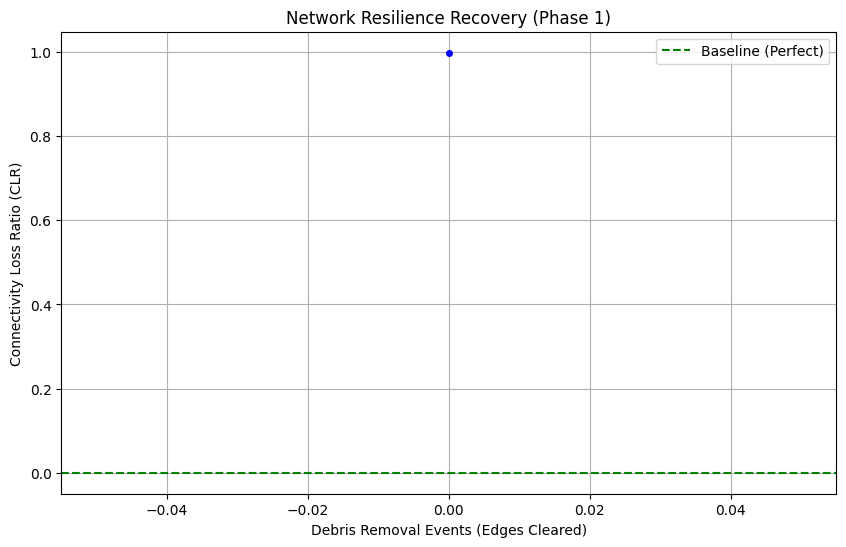

Final CLR after Operations: 99.8136%


In [ ]:
# ==========================================
# C. DYNAMIC CLR ANALYSIS (GRAPH SIMULATION)
# ==========================================
import matplotlib.pyplot as plt
import csv

print("\n--- Starting Dynamic Resilience Analysis ---")

# 1. SETUP GRAPHS
# ----------------------------------------
# Ensure we have G_lkh (Nodes 1..N). If you only have G (OSMIDs), convert it:
if 'osmid_to_lkh' in locals():
    G_sim = nx.relabel_nodes(G, osmid_to_lkh)
else:
    # Fallback if running immediately after generation
    G_sim = G_lkh.copy()

# A. Create Baseline Graph (Perfect World: 20mph, No Blockages)
G_baseline = G_sim.copy()
for u, v, d in G_baseline.edges(data=True):
    # Length / Speed (m/min)
    dist = d.get('length_m', 1) # Ensure length_m was saved in Section 4!
    time_base = dist / ((20 * 1609.34) / 60) # 20mph
    G_baseline[u][v]['weight'] = time_base

# B. Create Initial Phase 1 Graph (Disaster World: 10mph + Penalty)
G_current = G_sim.copy()
# (Assuming G_sim already has the penalties from the generation step)

# 2. DEFINE EFFICIENCY FUNCTION
# ----------------------------------------
def get_efficiency(graph):
    n = len(graph)
    if n <= 1: return 0
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight='weight'))
    inv_sum = 0
    for u in path_lengths:
        for v, d in path_lengths[u].items():
            if u != v and d > 0:
                inv_sum += (1/d)
    return inv_sum / (n * (n - 1))

# Calculate Reference Values
print("Calculating Baseline Efficiency...")
eff_base = get_efficiency(G_baseline)
print(f"  > Baseline Efficiency: {eff_base:.4f}")

# 3. LOAD ROUTES
# ----------------------------------------
route_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\solution_routes.csv"
truck_paths = {}

try:
    with open(route_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            vid = int(row['Vehicle_ID'])
            nid = int(row['LKH_Node_ID'])
            if vid not in truck_paths: truck_paths[vid] = []
            truck_paths[vid].append(nid)
except FileNotFoundError:
    print("Error: Route CSV not found. Run the Solver script first!")
    truck_paths = {}

# 4. SIMULATION LOOP
# ----------------------------------------
print("Simulating Debris Clearance...")

# Flatten routes into a single timeline of steps
# (Simple assumption: Trucks move in parallel, but we serialize strictly by step index)
# Timeline: [ (Truck1, Step1), (Truck2, Step1), (Truck1, Step2)... ]
timeline = []
max_steps = max(len(p) for p in truck_paths.values()) if truck_paths else 0

for step in range(max_steps - 1):
    for vid, path in truck_paths.items():
        if step < len(path) - 1:
            u, v = path[step], path[step+1]
            timeline.append((u, v))

clr_history = []
cleared_edges = set()

# Initial State
curr_eff = get_efficiency(G_current)
start_clr = 1 - (curr_eff / eff_base)
clr_history.append(start_clr)

print(f"Start CLR: {start_clr:.2%}")

for i, (u, v) in enumerate(timeline):
    # Check if edge exists and is blocked
    if G_current.has_edge(u, v):
        edge_data = G_current[u][v]
        
        # Check if it was blocked (1) and not yet cleared
        if edge_data.get('blocked') == 1:
            
            # "Clear" the debris:
            # 1. Remove 'blocked' flag
            G_current[u][v]['blocked'] = 0
            
            # 2. Reset weight to Baseline (or Phase 1 unblocked speed)
            # Strategy: If cleared, do we go to 20mph (Baseline) or 10mph (Phase 1 clear)?
            # Let's assume Phase 1 clear (10mph) because trucks are still operating.
            dist = edge_data.get('length_m', 1)
            new_weight = dist / ((10 * 1609.34) / 60) # 10mph
            G_current[u][v]['weight'] = new_weight
            
            # 3. Recalculate Metrics
            curr_eff = get_efficiency(G_current)
            new_clr = 1 - (curr_eff / eff_base)
            
            # Optimization: Only record if CLR changed
            clr_history.append(new_clr)
            
            print(f"  > Step {i}: Cleared edge {u}-{v}. New CLR: {new_clr:.2%}")

# 5. VISUALIZATION
# ----------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(clr_history, marker='o', linestyle='-', color='b', markersize=4)
plt.title("Network Resilience Recovery (Phase 1)")
plt.xlabel("Debris Removal Events (Edges Cleared)")
plt.ylabel("Connectivity Loss Ratio (CLR)")
plt.grid(True)
plt.axhline(y=0, color='g', linestyle='--', label="Baseline (Perfect)")
plt.legend()
plt.show()

print(f"Final CLR after Operations: {clr_history[-1]:.4%}")


--- Starting Dynamic Resilience Analysis (Debug Mode) ---
Rebuilding Simulation Graph from CSV Data...
  > Simulation Graph Built: 227 nodes, 269 edges.
  > Blocked Edges in Graph: 8
Calculating Reference Efficiency...
  > Baseline Efficiency: 1.7515
  > Loaded routes for 6 vehicles.
Simulating Debris Clearance...
  > Start CLR: 50.23%
    [Step 9] Cleared Edge 50-58 -> CLR: 50.17%
    [Step 10] Cleared Edge 58-45 -> CLR: 50.10%
Simulation Complete.
  > Total Edges Traversed: 17
  > Blocked Edges Cleared: 2
  > Final CLR: 50.1018%


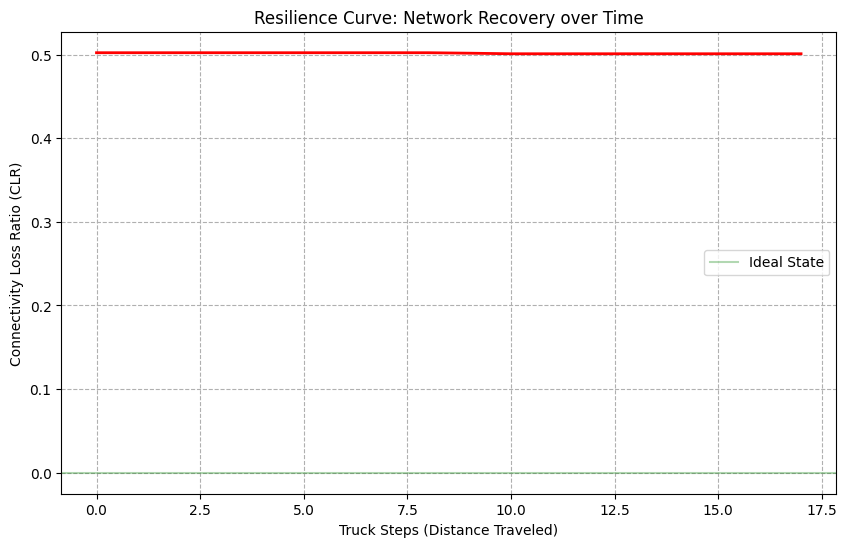

In [ ]:
# ==========================================
# C. DYNAMIC CLR ANALYSIS (ROBUST VERSION)
# ==========================================
import matplotlib.pyplot as plt
import csv
import networkx as nx

print("\n--- Starting Dynamic Resilience Analysis (Debug Mode) ---")

# 1. REBUILD GRAPH FROM DATA (To ensure IDs match Routes)
# ----------------------------------------
print("Rebuilding Simulation Graph from CSV Data...")

# Re-establish mappings just in case
final_osmids = df_nodes['osmid'].unique()
osmid_to_lkh_sim = {osmid: i+1 for i, osmid in enumerate(final_osmids)}

G_sim = nx.Graph()

# Add Nodes
for i in range(1, len(final_osmids)+1):
    G_sim.add_node(i)

# Add Edges (Map u/v to LKH IDs 1..N)
blocked_edge_count = 0
for idx, row in df_edges.iterrows():
    if row['u'] in osmid_to_lkh_sim and row['v'] in osmid_to_lkh_sim:
        u_lkh = osmid_to_lkh_sim[row['u']]
        v_lkh = osmid_to_lkh_sim[row['v']]
        
        # Current Weight (Phase 1: 10mph + Penalty)
        # 10 mph = ~268 meters/min
        dist = row['length']
        time_phase1 = dist / 268.0 
        is_blocked = 0
        
        if row['blocked'] == 1:
            time_phase1 += 60 # Add penalty
            is_blocked = 1
            blocked_edge_count += 1
            
        G_sim.add_edge(u_lkh, v_lkh, weight=time_phase1, length_m=dist, blocked=is_blocked)

print(f"  > Simulation Graph Built: {len(G_sim.nodes)} nodes, {len(G_sim.edges)} edges.")
print(f"  > Blocked Edges in Graph: {blocked_edge_count}")

# 2. DEFINE BASELINE (Target State)
# ----------------------------------------
G_baseline = G_sim.copy()
for u, v, d in G_baseline.edges(data=True):
    # Baseline: 20mph (~536 m/min), No Penalty
    dist = d.get('length_m', 1)
    time_base = dist / 536.0
    G_baseline[u][v]['weight'] = time_base

# Efficiency Function
def get_efficiency(graph):
    n = len(graph)
    if n <= 1: return 0
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight='weight'))
    inv_sum = 0
    for u in path_lengths:
        for v, d in path_lengths[u].items():
            if u != v and d > 0:
                inv_sum += (1/d)
    return inv_sum / (n * (n - 1))

print("Calculating Reference Efficiency...")
eff_base = get_efficiency(G_baseline)
print(f"  > Baseline Efficiency: {eff_base:.4f}")

# 3. LOAD ROUTES
# ----------------------------------------
route_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\solution_routes.csv"
truck_paths = {}

try:
    with open(route_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            vid = int(row['Vehicle_ID'])
            nid = int(row['LKH_Node_ID'])
            if vid not in truck_paths: truck_paths[vid] = []
            truck_paths[vid].append(nid)
    print(f"  > Loaded routes for {len(truck_paths)} vehicles.")
except FileNotFoundError:
    print("  > ERROR: Route CSV not found. Please run the Solver Script first!")

# 4. SIMULATION LOOP
# ----------------------------------------
print("Simulating Debris Clearance...")

# Flatten routes
timeline = []
max_steps = max(len(p) for p in truck_paths.values()) if truck_paths else 0

for step in range(max_steps - 1):
    for vid, path in truck_paths.items():
        if step < len(path) - 1:
            u, v = path[step], path[step+1]
            timeline.append((u, v))

# Initial CLR
G_current = G_sim.copy()
curr_eff = get_efficiency(G_current)
start_clr = 1 - (curr_eff / eff_base)
clr_history = [start_clr]

print(f"  > Start CLR: {start_clr:.2%}")

cleared_count = 0
traversed_count = 0

for u, v in timeline:
    if G_current.has_edge(u, v):
        traversed_count += 1
        edge_data = G_current[u][v]
        
        # DEBUG: Check if we are hitting blocked edges
        if edge_data.get('blocked') == 1:
            # CLEAR THE EDGE
            cleared_count += 1
            
            # 1. Remove Blocked Flag
            G_current[u][v]['blocked'] = 0
            
            # 2. Improve Speed (Set to 10mph, no penalty)
            # We assume Phase 1 operations (10mph) even after clearing
            dist = edge_data.get('length_m', 1)
            new_weight = dist / 268.0 
            G_current[u][v]['weight'] = new_weight
            
            # 3. Recalculate
            curr_eff = get_efficiency(G_current)
            new_clr = 1 - (curr_eff / eff_base)
            clr_history.append(new_clr)
            
            # Print update every 5 clears to reduce spam
            if cleared_count % 1 == 0:
                print(f"    [Step {traversed_count}] Cleared Edge {u}-{v} -> CLR: {new_clr:.2%}")
        else:
            # Driving on already clear road, CLR stays same
            clr_history.append(clr_history[-1])
            
print(f"Simulation Complete.")
print(f"  > Total Edges Traversed: {traversed_count}")
print(f"  > Blocked Edges Cleared: {cleared_count}")
print(f"  > Final CLR: {clr_history[-1]:.4%}")

# 5. VISUALIZATION
# ----------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(clr_history, color='red', linewidth=2)
plt.title("Resilience Curve: Network Recovery over Time")
plt.xlabel("Truck Steps (Distance Traveled)")
plt.ylabel("Connectivity Loss Ratio (CLR)")
plt.grid(True, which='both', linestyle='--')
plt.axhline(y=0, color='green', linestyle='-', alpha=0.3, label="Ideal State")
plt.legend()
plt.show()


--- Starting Dynamic Resilience Analysis (Node-Based) ---
Rebuilding Simulation Graph...
  > Baseline Efficiency: 1.7515
Simulating Debris Clearance...
  > Start CLR: 50.23%
    [Visit 61] Serviced Node 61 -> CLR: 50.16%
    [Visit 144] Serviced Node 50 -> CLR: 50.11%
    [Visit 146] Serviced Node 58 -> CLR: 50.04%
    [Visit 148] Serviced Node 45 -> CLR: 50.00%
Simulation Complete.
  > Nodes Visited: 235
  > Edges Cleared: 4
  > Final CLR: 50.0000%


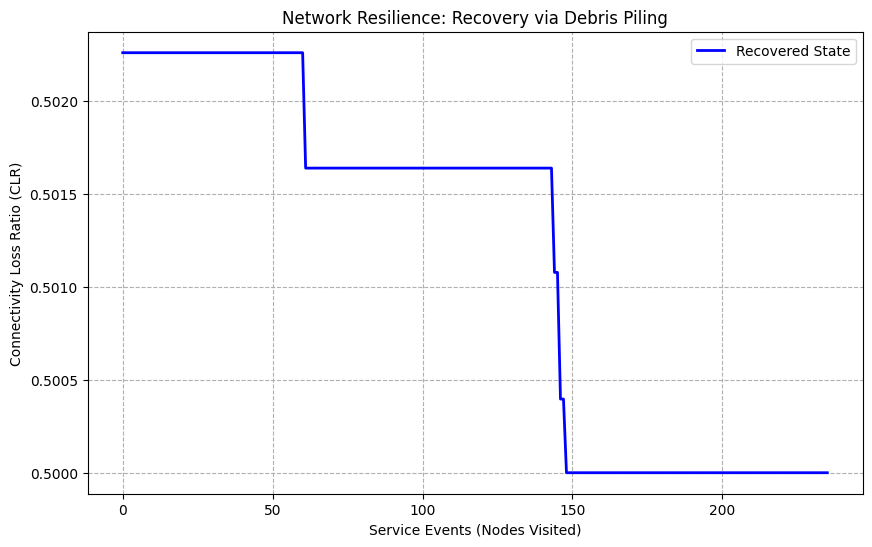

In [ ]:
# ==========================================
# C. DYNAMIC CLR ANALYSIS (NODE-BASED CLEARING)
# ==========================================
import matplotlib.pyplot as plt
import csv
import networkx as nx

print("\n--- Starting Dynamic Resilience Analysis (Node-Based) ---")

# 1. REBUILD GRAPH
# ----------------------------------------
print("Rebuilding Simulation Graph...")
final_osmids = df_nodes['osmid'].unique()
osmid_to_lkh_sim = {osmid: i+1 for i, osmid in enumerate(final_osmids)}

G_sim = nx.Graph()
for i in range(1, len(final_osmids)+1): G_sim.add_node(i)

blocked_edge_map = {} # Map Node ID -> List of (u, v) blocked edges connected to it

for idx, row in df_edges.iterrows():
    if row['u'] in osmid_to_lkh_sim and row['v'] in osmid_to_lkh_sim:
        u_lkh = osmid_to_lkh_sim[row['u']]
        v_lkh = osmid_to_lkh_sim[row['v']]
        
        # Phase 1 Weight (10mph + Penalty)
        dist = row['length']
        time_phase1 = dist / 268.0 
        is_blocked = 0
        
        if row['blocked'] == 1:
            time_phase1 += 60
            is_blocked = 1
            
            # Record that this edge belongs to these nodes for clearing later
            if u_lkh not in blocked_edge_map: blocked_edge_map[u_lkh] = []
            if v_lkh not in blocked_edge_map: blocked_edge_map[v_lkh] = []
            blocked_edge_map[u_lkh].append((u_lkh, v_lkh))
            blocked_edge_map[v_lkh].append((u_lkh, v_lkh))
            
        G_sim.add_edge(u_lkh, v_lkh, weight=time_phase1, length_m=dist, blocked=is_blocked)

# 2. DEFINE BASELINE
# ----------------------------------------
G_baseline = G_sim.copy()
for u, v, d in G_baseline.edges(data=True):
    dist = d.get('length_m', 1)
    G_baseline[u][v]['weight'] = dist / 536.0 # 20mph

def get_efficiency(graph):
    n = len(graph)
    if n <= 1: return 0
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(graph, weight='weight'))
    inv_sum = 0
    for u in path_lengths:
        for v, d in path_lengths[u].items():
            if u != v and d > 0:
                inv_sum += (1/d)
    return inv_sum / (n * (n - 1))

eff_base = get_efficiency(G_baseline)
print(f"  > Baseline Efficiency: {eff_base:.4f}")

# 3. LOAD ROUTES & FLATTEN
# ----------------------------------------
route_path = r"C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization\output\1. Setup\focus area test\solution_routes.csv"
truck_visits = [] # List of nodes visited in order

try:
    with open(route_path, 'r') as f:
        reader = csv.DictReader(f)
        # Sort by Step_Order to simulate timeline
        sorted_rows = sorted(reader, key=lambda x: (int(x['Step_Order']), int(x['Vehicle_ID'])))
        for row in sorted_rows:
            truck_visits.append(int(row['LKH_Node_ID']))
except FileNotFoundError:
    print("  > ERROR: Route CSV not found.")

# 4. SIMULATION LOOP (VISIT = CLEAR)
# ----------------------------------------
print("Simulating Debris Clearance...")

G_current = G_sim.copy()
start_clr = 1 - (get_efficiency(G_current) / eff_base)
clr_history = [start_clr]

print(f"  > Start CLR: {start_clr:.2%}")

cleared_count = 0
nodes_processed = 0

for node_id in truck_visits:
    nodes_processed += 1
    
    # CHECK: Does this node have attached blocked edges?
    if node_id in blocked_edge_map:
        edges_to_clear = blocked_edge_map[node_id]
        change_made = False
        
        for u, v in edges_to_clear:
            if G_current[u][v].get('blocked') == 1:
                # CLEAR IT
                G_current[u][v]['blocked'] = 0
                dist = G_current[u][v].get('length_m', 1)
                G_current[u][v]['weight'] = dist / 268.0 # Set to clear speed (10mph)
                
                cleared_count += 1
                change_made = True
        
        if change_made:
            curr_eff = get_efficiency(G_current)
            new_clr = 1 - (curr_eff / eff_base)
            clr_history.append(new_clr)
            # Remove from map so we don't clear it twice
            del blocked_edge_map[node_id]
            print(f"    [Visit {nodes_processed}] Serviced Node {node_id} -> CLR: {new_clr:.2%}")
        else:
            clr_history.append(clr_history[-1])
    else:
        clr_history.append(clr_history[-1])

print(f"Simulation Complete.")
print(f"  > Nodes Visited: {nodes_processed}")
print(f"  > Edges Cleared: {cleared_count}")
print(f"  > Final CLR: {clr_history[-1]:.4%}")

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.plot(clr_history, color='blue', linewidth=2, label='Recovered State')
plt.title("Network Resilience: Recovery via Debris Piling")
plt.xlabel("Service Events (Nodes Visited)")
plt.ylabel("Connectivity Loss Ratio (CLR)")
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [ ]:
# 1. SETUP & CONFIGURATION

import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
critical_path = os.path.join(input_base, 'focus_area_fire_station.csv')
raster_path = os.path.join(input_base, 'Raster Data.tif')
output_vrp_path = os.path.join(output_dir, 'Phase1_Debris_Final.vrp')

# Parameters
SPEED_MPH = 10 # CHANGE PARAMETER
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
print
DEBRIS_TRAVEL_PENALTY_MIN = 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# LKH Constraints
CAPACITY_LIMIT = 480  # Max Piling Time per truck
DISTANCE_LIMIT = 600  # Max Travel+Service Time per truck
VEHICLES_COUNT = 5    # Increased to ensure feasibility
NUM_RESIDENTIAL_NODES = 20



# 2. LOAD DATA

print("Loading Spatial Data...")
df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_critical = pd.read_csv(critical_path)

# Convert WKT
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
df_critical['geometry'] = df_critical['WKT'].apply(wkt.loads)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_critical = gpd.GeoDataFrame(df_critical, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")

Loading Spatial Data...


In [ ]:
# 1. SETUP & CONFIGURATION

import os
import random
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point

os.chdir(r'C:\Users\leanh\Documents\GitHub\Debris-Removal-Optimization')
script_directory = os.path.dirname(__file__)
input_base = os.path.join(script_directory, 'input', 'QGIS', 'focus area test')
output_dir = os.path.join(script_directory, 'output', '1. Setup', 'focus area test')
os.makedirs(output_dir, exist_ok=True)

# Files
edge_path = os.path.join(input_base, 'focus_area_edges.csv')
node_path = os.path.join(input_base, 'focus_area_nodes.csv')
depot_path = os.path.join(input_base, 'focus_area_dms.csv')
critical_path = os.path.join(input_base, 'focus_area_fire_station.csv')
raster_path = os.path.join(input_base, 'Raster Data.tif')
output_vrp_path = os.path.join(output_dir, 'Phase1_Debris_Final.vrp')

# Parameters
SPEED_MPH = 10 # CHANGE PARAMETER
SPEED_METERS_PER_MIN = (SPEED_MPH * 1609.34) / 60
print
DEBRIS_TRAVEL_PENALTY_MIN = 60
ROAD_WIDTH_FT = 24
BLOCKAGE_THRESHOLD = 0.50

# LKH Constraints
CAPACITY_LIMIT = 480  # Max Piling Time per truck
DISTANCE_LIMIT = 600  # Max Travel+Service Time per truck
VEHICLES_COUNT = 5    # Increased to ensure feasibility
NUM_RESIDENTIAL_NODES = 20



# 2. LOAD DATA

df_edges = pd.read_csv(edge_path)
df_nodes = pd.read_csv(node_path)
df_depot = pd.read_csv(depot_path)
df_critical = pd.read_csv(critical_path)

# Convert WKT
df_edges['geometry'] = df_edges['WKT'].apply(wkt.loads)
df_nodes['geometry'] = df_nodes['WKT'].apply(wkt.loads)
df_critical['geometry'] = df_critical['WKT'].apply(wkt.loads)

# GeoDataFrames
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")
gdf_critical = gpd.GeoDataFrame(df_critical, geometry='geometry', crs="EPSG:4326")

# Project to Meters
gdf_edges_proj = gdf_edges.to_crs("EPSG:3857")
gdf_nodes_proj = gdf_nodes.to_crs("EPSG:3857")